This notebook is used to walk through building up an MAE using a subset of the Dec 17, 2023 Nore'easter data. Data is 239 images from epoch num: 1702827001820. The data was made in metashape using the most recent method of using camera extrinsics. 

The first iteration of the model uses only 1 transect in time for training and testing data. Then the model builds up to use the whole spatial extent of the DEM for training data, while predicting on the same transect in each iteration.

In [1]:
import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import tensorflow as tf
import os
import glob
import mat73

from sklearn.metrics import accuracy_score, precision_score, recall_score
from sklearn.model_selection import train_test_split
from tensorflow.keras import layers, losses
#from tensorflow.keras.datasets import fashion_mnist (fake data)
from tensorflow.keras.models import Model
from PIL import Image
from scipy.io import loadmat

2026-07-14 13:40:04.540039: I tensorflow/core/platform/cpu_feature_guard.cc:182] This TensorFlow binary is optimized to use available CPU instructions in performance-critical operations.
To enable the following instructions: AVX2 FMA, in other operations, rebuild TensorFlow with the appropriate compiler flags.


In [2]:
# paths
MAE_datapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data"
rawdatapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/videos/Transect_y7_3/2yavg/transects_7.3_2.mat"
traindatapath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/videos/1702827001820_transects.mat" # change this
savepath=r"/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/L2R_results_prelim/building_upL2R/iteration1"

Load and prep data

In [29]:
# load in matfile and convert
raw_transects=loadmat(rawdatapath)
transects=raw_transects['ztran']
transect_df_raw=pd.DataFrame(transects) # convert to dataframe
print(transect_df_raw.shape)

(551, 239)


In [30]:
raw_mat=loadmat(traindatapath)
train_struct=raw_mat['all_trans_struct']

all_trans=[]
names=[]

for elem in train_struct.ravel():
    name=elem['name'].item()
    data_matrix=elem['data']

    temp_df=pd.DataFrame(data_matrix)
    temp_df['name']=name

    all_trans.append(temp_df)
    names.append(name)

        
train_trans_df=pd.concat(all_trans,axis=0,keys=names, names=['transect_name','original_index'])
train_ds=train_trans_df.drop(columns=['name'])
print("Dataset Shape:", train_ds.shape)
print("\nFirst few rows of the Transect Dataframe:")
print(train_ds.head())


Dataset Shape: (20938, 239)

First few rows of the Transect Dataframe:
                              0    1    2    3    4    5    6    7    8    \
transect_name original_index                                                
transect_y-60 0               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              1               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              2               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              3               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              4               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   

                              9    ...  229  230  231  232  233  234  235  \
transect_name original_index       ...                                      
transect_y-60 0               NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              1               NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
              2               NaN  ...  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
    

In [31]:
# need to make transect and training data normalized on the same scale
from sklearn.preprocessing import MinMaxScaler
global_scaler=MinMaxScaler()
combined_raw_data=pd.concat([transect_df_raw,train_ds],axis=0)
global_scaler.fit(combined_raw_data.values.reshape(-1,1))
#function to transform ds
def scale_dataframe(df,fitted_scalar):
    scaled_matrix=df.values.copy()
    gaps_mask=np.isnan(scaled_matrix)

    flat_vals=scaled_matrix.reshape(-1,1)
    flat_vals[~np.isnan(flat_vals)]=fitted_scalar.transform(flat_vals[~np.isnan(flat_vals)].reshape(-1,1)).flatten()
    scaled_df=pd.DataFrame(flat_vals.reshape(df.shape),columns=df.columns,index=df.index)
    return scaled_df

train_df_norm=scale_dataframe(train_ds,global_scaler)
train_df_norm_nodune=train_df_norm.iloc[200:,:]

transect_73=scale_dataframe(transect_df_raw,global_scaler)
transect_73_nodune=transect_73.iloc[200:,:]
#transect_df_norm=scale_dataframe(transect_df_raw,global_scaler)
#transect_df_norm_nodune=transect_df_norm[200:]
#train_df_norm=scale_dataframe(train_ds,global_scaler)
#train_df_norm_nodune=train_df_norm[200:]

In [32]:
print(transect_73_nodune.shape)

(351, 239)


ITERATION 1: Using 1 transect for training, testing, and MAE reconstruction

In [7]:
# define model
class Denoise(Model):
    def __init__(self,window_size):
        super(Denoise,self).__init__()
        self.window_size=window_size

        self.encoder=tf.keras.Sequential([
            layers.Input(shape=(window_size,2)), # changed from none
            layers.Conv1D(32,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(16,3,activation='relu',padding='same',strides=2),
            layers.Conv1D(8,3,activation='relu',padding='same',strides=2) #maintain shape with strides=1
        ])

        self.decoder=tf.keras.Sequential([
            layers.Conv1DTranspose(8,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(16,3,strides=2,activation='relu',padding='same'),
            layers.Conv1DTranspose(32,3,strides=2,activation='relu',padding='same'),
            layers.Flatten(),
            layers.Dense(window_size,activation='sigmoid'),
            layers.Reshape((window_size,1))
        ])

    def call(self,x):
        encoded=self.encoder(x)
        decoded=self.decoder(encoded)
        return decoded
    
    def train_step(self,data):
        # to get input tensor (x_input,y) from .map() in mask
        x_input,y, mask,start_idx,t_step = data #(batch,10,2) (batch,10,1) (batch,10,1)

        with tf.GradientTape() as tape: 
            # forward pass using x_masked
            y_pred=self(x_input,training=True)
            mse=tf.square(y_pred-y) #calc loss
            masked_mse=mse*(1.0 - mask) # masked loss
            loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points
           
        trainable_vars=self.trainable_variables
        gradients=tape.gradient(loss,trainable_vars)
        self.optimizer.apply_gradients(zip(gradients,trainable_vars))

        return{"loss":loss}
    
    def test_step(self,data):
         # to get input tensor
        x,y,mask,start_idx,t_step=data
 
        y_pred=self(x,training=False)
        mse=tf.square(y_pred-y) #calc loss
        masked_mse=mse*(1.0 - mask) # masked loss
        loss=tf.reduce_sum(masked_mse)/(tf.reduce_sum(1.0-mask)+1e-6) # mean sq error over just masked points

        return {"loss":loss}

def gap_mask(x,mask_ratio):
     #batch_size=tf.shape(x)[0]
     length=tf.shape(x)[0]# number of things in x, x is (10,1)

     gap_size=tf.cast(tf.cast(length,tf.float32)*mask_ratio,tf.int32) # how many elements to be masked (length of window*maskratio)
     gap_size=tf.maximum(gap_size,1) # no zero lengths aka at least one thing is masked
     max_start=tf.maximum(length-gap_size,0) #mask starts inside window

     start=tf.random.uniform([],minval=0,maxval=max_start+1,dtype=tf.int32) # random start of mask

     range_idx=tf.range(length) # (length,) 
     #boolean mask
     if_in_gap=tf.logical_and(range_idx>=start,range_idx<(start+gap_size))

     gap_mask_tensor=tf.cast(if_in_gap,tf.float32)
     gap_mask_tensor=tf.expand_dims(gap_mask_tensor,-1) # 1 at gap, 0 everywhere else (batch,length,1)
     mask=1-gap_mask_tensor
     x_masked=x*mask
     return x_masked,mask

def random_mask(x,mask_ratio):
    mask=tf.cast(tf.random.uniform(tf.shape(x))>mask_ratio,tf.float32) # mask is is (batch,length,1) and x_masked is (batch,length,2)
    x_masked=x*mask
    return x_masked, mask


def masking_layer(x,start,t_step):
    window_size=tf.shape(x)[0]
    x=tf.reshape(tf.cast(x,tf.float32),[window_size,1]) # 10 is window length
    mask_ratio=tf.random.uniform([],0.1,0.8) #mask possibilities of 10-80%

    use_gaps=tf.random.uniform([])<0.7 #random chosen number to use this mask method
    #mask via gap and random method
    x_masked,mask=tf.cond(use_gaps,lambda: gap_mask(x,mask_ratio),lambda: random_mask(x,mask_ratio))
    x_input=tf.concat([x_masked,mask],axis=-1) # now (1,length,2)
    return x_input,x, mask, start, t_step# (given data and target/real og data)


In [8]:
def run_MAE(window_size,df,split_windows_idx, epochs=20, batch_size=16):
    # run MAE training cycle per targeted window size
    timesteps=sorted(split_windows_idx.keys()) #chronological order
    n=len(timesteps)

    # train/val/test bounds
    train_end=int(n*0.7)
    val_end=int(n*0.85)

    train_time=timesteps[:train_end] #slice to grab train/test/val
    val_time=timesteps[train_end:val_end]
    test_time=timesteps[val_end:]

    def grab_windows(time_list): #loop through list of timesteps grab columnmand store as numpy vector
        X, info = [],[]
        for t in time_list:
            transect=df[t].values
            for (start,stop) in split_windows_idx[t]: # windows of chosen size
                X.append(transect[start:stop])
                info.append({'timestep':t,'start':start,'stop':stop}) # store location to put back together
        return np.array(X, dtype="float32"), info
    
    X_train, info_train=grab_windows(train_time)
    X_val, info_val=grab_windows(val_time)
    X_test, info_test=grab_windows(test_time)

    # create ds function (mem efficient)
    def build_ds(X,info):
        starts=np.array([i['start'] for i in info]) # start points spatial
        tsteps=np.array([i['timestep'] for i in info]) # end points spatial
        ds=tf.data.Dataset.from_tensor_slices((X,starts,tsteps)) # arrays into TensorFlow tensor slice ds
        # mask over transect windows, process masks concureently, batches of 16, prep batch n+1 while working on current batch (efficiency)
        return (ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE))
    
    train_ds=build_ds(X_train,info_train)
    test_ds=build_ds(X_test,info_test)
    val_ds=build_ds(X_val,info_val)

    # inirialize model
    model=Denoise(window_size=window_size)
    model.compile(optimizer='adam')

    print(f"Training started for window size: {window_size} (train shape: {X_train.shape})")
    history=model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    return model, history, test_ds

In [9]:
def is_gap_too_big(mask,window_size):
    mask_str="".join(mask.astype(int).astype(str))
    return "0"*window_size in mask_str

In [10]:
def reconstruct_ds_with_MAE(model, current_df, active_mask_df, window_size, stride=5):
    # slides MAE over the transects from left to right to impute where gaps exist
    # returns newly filled dataset
    x_matrix=tf.convert_to_tensor(current_df.values,dtype=tf.float32) # dataframe to tensorflow float 32
    transect_pts,tsteps=x_matrix.shape # length or cross-shore, timesteps
    mask_matrix=active_mask_df.values.astype(np.float32)

    reconstructed_all=[]

    for i in range(tsteps): # loop through every time step
        x_1dim=x_matrix[:,i].numpy() #current transect
        mask_1dim=mask_matrix[:,i] #gaps present in og or prev reconstrcution
        valid_indices=np.where(mask_1dim==1.0)[0]
        if len(valid_indices)>0:
            last_valid_index=valid_indices[-1]
        else:
            last_valid_index=-1

        full_recon=np.zeros_like(x_1dim) 
        counts=np.zeros_like(x_1dim)

        # slide window over full transect profile
        for start in range(0,transect_pts-window_size+1,stride):
            end=start+window_size
            #window_raw=raw_1dim[start:end] # window of raw data
            window_data=np.nan_to_num(x_1dim[start:end]) #slice of transect any nans to 0 current df
            window_mask=mask_1dim[start:end] #
            #model input shape
            combined_input=np.stack([window_data,window_mask],axis=-1).reshape(1,window_size,2) # transect slice with batch dim
            # CHECKS
            is_already_full = np.all(window_mask == 1.0) # check if window is full
            has_gap_inside = np.any(window_mask == 0.0) #double check there actually is a gap inside to fix (at least 1 point)

            if is_already_full:# PATH1: do not predict if full of data
                #keep full window
                full_recon[start:end] = np.nansum([full_recon[start:end], window_data], axis=0)
                counts[start:end] += 1
                continue

            if has_gap_inside: # PATH2: predict in window
                gap_indices=np.where(window_mask==0.0)[0]
                total_real_data_pts=np.sum(window_mask==1.0)
                min_context_pts=1 #threshold of at least one point
                has_any_local_context=total_real_data_pts>=min_context_pts

                full_gap_idx=start+gap_indices[0]
                g_start=full_gap_idx
                if is_gap_too_big(window_mask,window_size=window_size):
                    #g_start=full_gap_idx
                    while g_start>0 and mask_1dim[g_start-1]==0.0:
                        g_start-=1
                    g_end=start+gap_indices[-1]
                    while g_end<transect_pts-1 and mask_1dim[g_end+1]==0.0:
                        g_end+=1
                    gap_size=g_end - g_start +1
                    print(f"gap size is {gap_size}")
                    if gap_size > window_size: # gap too big (outside of window)
                        print(f"t index {i} skipped gap ({start}:{end}) too large")
                        continue
                # Check1: Is it bounded by real data on window edge?
                has_bounds=(window_mask[0]==1.0) and (window_mask[-1]==1.0)
                # Check2: if on window edge, is there data outside of window edge
                left_bound=(window_mask[0]==1.0) or (start>0 and mask_1dim[start-1]==1.0) #or (start==0)
                right_bound=(window_mask[-1]==1.0) or (end<transect_pts and mask_1dim[end]==1) #or (end==transect_pts)
                both_sides_bounded=left_bound or right_bound
                is_bounded=both_sides_bounded or has_bounds
                if has_any_local_context and is_bounded:
                    model_recon = model.predict(combined_input, verbose=0).flatten()
                    # keep original data
                    recon_window=np.where(window_mask==1.0,window_data,model_recon) # keep og data
                    #preds for avg
                    #pred_only_window=np.where(window_mask==0.0,model_recon,0.0)
                    full_recon[start:end] = np.nansum([full_recon[start:end], recon_window], axis=0)
                    counts[start:end] += (window_mask==0.0).astype(float) # this only increments up where there are actual gaps


        raw_prediction=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0) # combine any overlapping predictions
        nan_indices=np.isnan(raw_prediction) # where gaps are missed bc at edge or too big of window

        # get rid of prediction into the abysss
        if last_valid_index !=-1 and last_valid_index<len(raw_prediction)-1:
            raw_prediction[last_valid_index+1:]=np.nan
        final_transect=raw_prediction.copy()
        is_gap=(mask_1dim==0) # find gap
        gap_changes=np.diff(is_gap.astype(int))

        gap_starts=np.where(gap_changes==1)[0]+1
        gap_ends=np.where(gap_changes==-1)[0]

        # at the edge
        if is_gap[0]: gap_starts= np.insert(gap_starts,0,0)
        if is_gap[-1]: gap_ends=np.append(gap_ends,len(is_gap)-1)
        # smooth over transistion (2-4 data points of smoothing with favor to the real data)
        blend_zone=min(4,int(window_size/4)) # transistion blending margin
        for g_start,g_end in zip(gap_starts,gap_ends):
            current_gap_size=g_end-g_start+1
            if current_gap_size<=6: # don't blend over the small gaps
                continue
            #left side blend
            if g_start>blend_zone:
                anchor_val=x_1dim[g_start -1] #known real value
                for b in range(blend_zone):
                    idx=g_start+b
                    if idx<= g_end and not np.isnan(raw_prediction[idx]):
                        # linear transition (Could do something better) from anchor to pred
                        alpha=(b+1)/(blend_zone +1)
                        final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
            #right side
            if g_end< len(x_1dim)-1:
                right_anchor_idx=min(len(x_1dim)-1,g_end+1)
                if mask_1dim[right_anchor_idx]==1.0: 
                    anchor_val=x_1dim[g_end+1]
                    for b in range(blend_zone):
                        idx=g_end-b
                        if idx>=g_start and not np.isnan(raw_prediction[idx]):
                            alpha=(b+1)/(blend_zone+1)
                            final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]

        # overide to keep og data (kind of like a fail safe if the rest didn't work)
        final_transect=np.where(mask_1dim==1.0,x_1dim,final_transect)
        #plot_timestep_reconstruction(x_1dim, mask_1dim, full_recon, counts, final_transect, timestep_idx=i) # plot for debugging
        reconstructed_all.append(final_transect)
    # return dataframe (points, timesteps)
    return pd.DataFrame(np.stack(reconstructed_all,axis=1),columns=current_df.columns)


In [11]:
def window_split(start,stop,size,overlap):
    return[(i,i+size) for i in range(start,stop-size+1,int(overlap))]

In [12]:
def find_windows_of_data(df,window_size,overlap_stride):
    # find the continous sections of data and extract window indices
    window_idx={}
    for timestep,transect in df.items():
        arg=transect.values
        masked=np.ma.masked_invalid(arg)
        clumps=np.ma.clump_unmasked(masked)
        window_idx[timestep]=[(s.start,s.stop)for s in clumps]

    split_windows_idx={}
    for timestep in window_idx:
        new_windows=[]
        for (start,stop) in window_idx[timestep]:
            length=stop-start
            if length>= window_size:
                new_windows.extend(window_split(start,stop,window_size,overlap_stride))
        split_windows_idx[timestep]=new_windows

    return split_windows_idx


In [13]:
from collections import Counter
def reeval_and_hist(active_mask_df,min_length,target_val=0,plot_histogram=True,stage_label=""):
    # functiin to histogram after reconstruction
    mask_matrix=active_mask_df.values
    spatial_pts,tsteps=mask_matrix.shape
    all_window_lengths=[]

    for col in range(tsteps):
        column=mask_matrix[:,col]
        is_target=(column==target_val) # find zeros
        # pad edges to get everything
        bound=np.hstack(([False],is_target,[False]))
        diffs=np.diff(bound.astype(int))

        starts=np.where(diffs==1)[0]
        ends=np.where(diffs==-1)[0]
        lengths=ends-starts

        all_window_lengths.extend(lengths)

    filtered_lengths=[l for l in all_window_lengths if l>=min_length]

    freq_map=Counter(filtered_lengths)
    mode_size=freq_map.most_common(1)[0][0]

    print(f"mode: {mode_size}")
    print(f"max length: {max(filtered_lengths)}")
    print(f"min length: {min(filtered_lengths)}")

    if plot_histogram:
        plt.figure(figsize=(9,4))
        plt.hist(filtered_lengths,bins=np.arange(min(all_window_lengths)-0.5, max(all_window_lengths)+0.5,1),color='pink',edgecolor='deeppink',alpha=0.7)
        plt.axvline(mode_size,color='black',linestyle='--',linewidth=2,label=f'Mode:{mode_size}')
        plt.title(f'distribution of continous data segments')
        plt.xlabel('segment length')
        plt.ylabel('freq')
        plt.legend()
        plt.grid(axis='y',linestyle=':',alpha=0.6)
        plt.show()

        return mode_size


In [14]:
# plotting functions
from matplotlib.animation import FuncAnimation
def save_stage_comparison_plots(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs"):
    """
    Plots and saves static comparisons showing the full profile (including dune),
    with the localized reconstructions overlaid at their proper positions.
    """
    os.makedirs(stage_dir, exist_ok=True)
    timesteps_to_plot = [0, 10, 20, 40, 60]
   
    # Define the spatial offset used during the .iloc[200:] slicing stage
    DUNE_OFFSET = 200
   
    for t in timesteps_to_plot:
        if t not in orig_full_df.columns:
            continue
           
        # 1. Grab the absolute raw baseline profile (including the dune)
        full_original = orig_full_df[t].values
        full_mask = ~np.isnan(full_original)
       
        # 2. Reconstruct the full coordinate line by stitching the original dune
        # together with the lower-beach patch provided by the current model stage
        full_reconstructed = full_original.copy()
       
        # Patch the trained window predictions over the lower-beach section
        # (This correctly aligns the model's indices starting from index 200 onward)
        full_reconstructed[DUNE_OFFSET:] = recon_no_dune_df[t].values

        plt.figure(figsize=(12, 4))
       
        # Plot the complete original line (dune + beach)
        plt.plot(full_original, color='blue', label='Original (with Dune)', alpha=0.8)
       
        # Overlay the reconstructed line
        plt.plot(full_reconstructed, color='deeppink', linewidth=2, linestyle='dashed',
                 label=f'Reconstructed (MAE-{window_size})')

        # Highlight missing gap regions across the entire profile layout
        plt.fill_between(
            np.arange(len(full_original)),
            np.nanmin(full_original) - 0.1,
            np.nanmax(full_original) + 0.1,
            where=~full_mask,
            color='gray',
            alpha=0.15,
            label='Missing Data Gap'
        )

        # Draw a vertical line denoting where the dune ends and the model zone begins
        plt.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.5, label='Dune Cutoff boundary')

        plt.title(f"Stage MAE-{window_size} Full Profile Reconstruction - Timestep {t}")
        plt.xlabel("Full Cross-shore index (Including Dune)")
        plt.ylabel("Normalized Elevation")
        plt.legend(loc='lower left')
        plt.tight_layout()
       
        # Save plot out
        plot_path = os.path.join(stage_dir, f"full_recon_stage_MAE{window_size}_timestep{t}.png")
        plt.savefig(plot_path, dpi=200)
        plt.close()


In [15]:
def save_stage_video_animation(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs", interval=500):
    """
    Creates and saves a dynamic video tracking profile repairs over time,
    maintaining the unedited dune profile on the left.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    DUNE_OFFSET = 200
    orig_full_data = orig_full_df.values
    recon_no_dune_data = recon_no_dune_df.values
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(12, 5))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1, np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Full Cross-shore index")
    ax.set_ylabel("Normalized Elevation")
   
    # Initialize baseline handles
    line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
    line_orig, = ax.plot([], [], color='blue', alpha=0.6, label='Original Survey (with Dune)')
    #line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
   
    # Draw static divider indicator
    ax.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.4)
    ax.legend(loc='lower left')

    # gaps as highlights
    gap_spans=[]
    gap_patch=plt.Rectangle((0,0),1,1,fc="gray", alpha=0.3,label='gaps')
    ax.legend(handles=[line_orig,line_recon,gap_patch],loc='lower left')

    def update(frame):
        nonlocal gap_spans
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
        y_orig = orig_full_data[:, frame]
       
        # Stitch the original dune to the model's currently filled lower beach
        y_recon_full = y_orig.copy()
        y_recon_full[DUNE_OFFSET:] = recon_no_dune_data[:,frame]

        is_gap=np.isnan(y_orig)
        is_gap[:DUNE_OFFSET]=False #ignore gaps in dune

        if np.any(is_gap):
            diff=np.diff(is_gap.astype(int))
            gap_starts=np.where(diff==1)[0]+1
            gap_ends=np.where(diff==-1)[0]+1

            if is_gap[0]:
                gap_starts=np.insert(gap_starts,0,0)
            if is_gap[-1]:
                gap_ends=np.append(gap_ends,n_points-1)

            for start,end in zip(gap_starts, gap_ends):
                span=ax.axvspan(start,end,color='gray',alpha=0.25,zorder=0)
                gap_spans.append(span)

       
        line_recon.set_data(x_coords, y_recon_full)
        line_orig.set_data(x_coords, y_orig)
        #line_recon.set_data(x_coords, y_recon_full)
       
        ax.set_title(f"Full Reconstruction | Stage: MAE-{window_size} | Timestep: {frame}")
        return [line_orig, line_recon] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"full_profile_stage_MAE{window_size}.gif")
    anim.save(video_path, writer="pillow")
    plt.close()


In [16]:
# loss and error plotting functiosn
def save_stage_loss_plot(history, window_size, stage_dir="noreaster_stage_results"):
    """
    Plots and saves the training vs validation loss across epochs for a specific stage.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    plt.figure(figsize=(7, 4))
    plt.plot(history.history['loss'], label='Training Loss', color='teal', linewidth=2)
    if 'val_loss' in history.history:
        plt.plot(history.history['val_loss'], label='Validation Loss', color='coral', linewidth=2, linestyle='--')
       
    plt.title(f"Stage MAE-{window_size} Learning Curves")
    plt.xlabel("Epochs")
    plt.ylabel("Loss (MSE)")
    plt.legend()
    plt.grid(True, linestyle=':', alpha=0.6)
    plt.tight_layout()
   
    plot_path = os.path.join(stage_dir, f"loss_curve_MAE{window_size}.png")
    plt.savefig(plot_path, dpi=200)
    plt.close()

In [17]:
import os
import matplotlib.pyplot as plt

def save_stage_loss_plot(history, window_size, stage_dir='stage_results'):
    """
    Plots and saves the training (and validation) loss over epochs for a given training iteration.
    
    Parameters:
    -----------
    history : keras.callbacks.History or dict
        The training history object or dictionary returned by run_MAE.
    window_size : int
        The current window size used in this training iteration (used for the filename/title).
    stage_dir : str
        The directory path where the plot image will be saved.
    """
    # 1. Ensure the output directory exists
    os.makedirs(stage_dir, exist_ok=True)
    
    # 2. Extract the history dictionary if a Keras History object is passed
    if hasattr(history, 'history'):
        history_dict = history.history
    else:
        history_dict = history

    # 3. Retrieve loss arrays
    loss = history_dict.get('loss', [])
    val_loss = history_dict.get('val_loss', [])
    epochs = range(1, len(loss) + 1)

    if len(loss) == 0:
        print(f"Warning: No 'loss' data found in history for window size {window_size}.")
        return

    # 4. Generate the plot
    plt.figure(figsize=(8, 5))
    plt.plot(epochs, loss, color='#1f77b4', linestyle='-', linewidth=2, label='Training Loss')
    
    if val_loss:
        plt.plot(epochs, val_loss, color='#d62728', linestyle='--', linewidth=2, label='Validation Loss')
        
    plt.title(f'Training Loss (Window Size: {window_size})', fontsize=14, fontweight='bold', pad=15)
    plt.xlabel('Epochs', fontsize=12)
    plt.ylabel('Loss', fontsize=12)
    plt.grid(True, linestyle='--', alpha=0.5)
    plt.legend(fontsize=11, loc='upper right')
    
    # 5. Save the figure with high resolution
    filename = f"loss_window_{window_size}.png"
    filepath = os.path.join(stage_dir, filename)
    plt.savefig(filepath, dpi=300, bbox_inches='tight')
    
    # 6. Close the plot to free memory (crucial inside a loop)
    plt.close()
    print(f"-> Successfully saved loss plot to: {filepath}")

In [18]:
print(transect_73.shape)

(551, 239)


In [19]:
print(transect_73_nodune.shape)

(351, 239)


iteration 1, window size = 10
Training started for window size: 10 (train shape: (7593, 10))
Epoch 1/30
474/474 [==============================] - 2s 3ms/step - loss: 6.1849e-04 - val_loss: 7.7294e-05
Epoch 2/30
474/474 [==============================] - 1s 3ms/step - loss: 7.5850e-05 - val_loss: 8.9784e-05
Epoch 3/30
474/474 [==============================] - 1s 3ms/step - loss: 7.5537e-05 - val_loss: 5.4809e-05
Epoch 4/30
474/474 [==============================] - 1s 3ms/step - loss: 7.5763e-05 - val_loss: 6.8528e-05
Epoch 5/30
474/474 [==============================] - 1s 3ms/step - loss: 7.5952e-05 - val_loss: 6.2454e-05
Epoch 6/30
474/474 [==============================] - 1s 3ms/step - loss: 7.4444e-05 - val_loss: 9.9025e-05
Epoch 7/30
474/474 [==============================] - 1s 3ms/step - loss: 7.5876e-05 - val_loss: 6.3934e-05
Epoch 8/30
474/474 [==============================] - 1s 3ms/step - loss: 7.5597e-05 - val_loss: 6.5251e-05
Epoch 9/30
474/474 [=======================

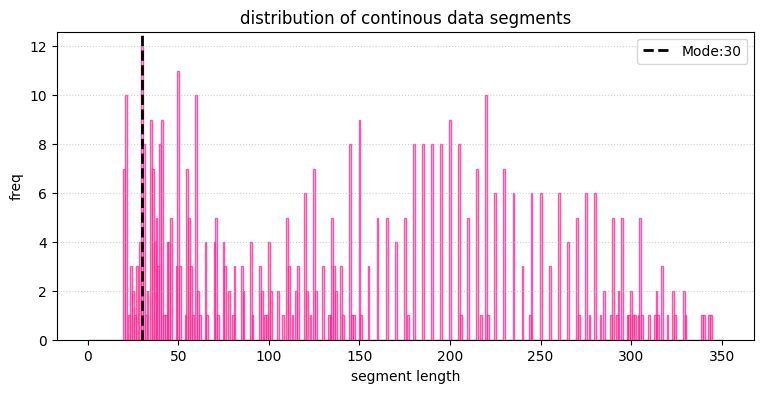

video of reconstruction
iteration done, moving to size 30
iteration 2, window size = 30
Training started for window size: 30 (train shape: (2809, 30))
Epoch 1/30
175/175 [==============================] - 2s 9ms/step - loss: 0.0015 - val_loss: 5.5581e-05
Epoch 2/30
175/175 [==============================] - 1s 8ms/step - loss: 7.5419e-05 - val_loss: 5.3954e-05
Epoch 3/30
175/175 [==============================] - 1s 7ms/step - loss: 7.4249e-05 - val_loss: 4.5817e-05
Epoch 4/30
175/175 [==============================] - 1s 8ms/step - loss: 7.5137e-05 - val_loss: 6.5705e-05
Epoch 5/30
175/175 [==============================] - 2s 9ms/step - loss: 7.5741e-05 - val_loss: 5.3861e-05
Epoch 6/30
175/175 [==============================] - 1s 8ms/step - loss: 7.5058e-05 - val_loss: 4.5406e-05
Epoch 7/30
175/175 [==============================] - 1s 8ms/step - loss: 7.4805e-05 - val_loss: 4.5596e-05
Epoch 8/30
175/175 [==============================] - 1s 8ms/step - loss: 7.6225e-05 - val_loss: 

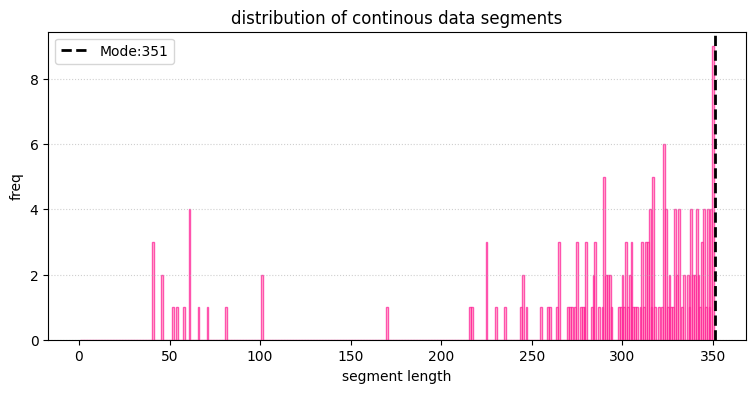

video of reconstruction
iteration done, moving to size 351
iteration 3, window size = 80
Training started for window size: 80 (train shape: (1081, 80))
Epoch 1/30
67/67 [==============================] - 2s 19ms/step - loss: 0.0022 - val_loss: 5.7050e-05
Epoch 2/30
67/67 [==============================] - 1s 17ms/step - loss: 1.2724e-04 - val_loss: 3.9143e-05
Epoch 3/30
67/67 [==============================] - 1s 17ms/step - loss: 1.3670e-04 - val_loss: 5.6378e-05
Epoch 4/30
67/67 [==============================] - 1s 17ms/step - loss: 1.1553e-04 - val_loss: 7.0600e-05
Epoch 5/30
67/67 [==============================] - 1s 16ms/step - loss: 1.0755e-04 - val_loss: 1.2987e-04
Epoch 6/30
67/67 [==============================] - 1s 16ms/step - loss: 9.6628e-05 - val_loss: 7.4209e-05
Epoch 7/30
67/67 [==============================] - 1s 17ms/step - loss: 1.0270e-04 - val_loss: 7.1993e-05
Epoch 8/30
67/67 [==============================] - 1s 17ms/step - loss: 9.6325e-05 - val_loss: 8.8160e

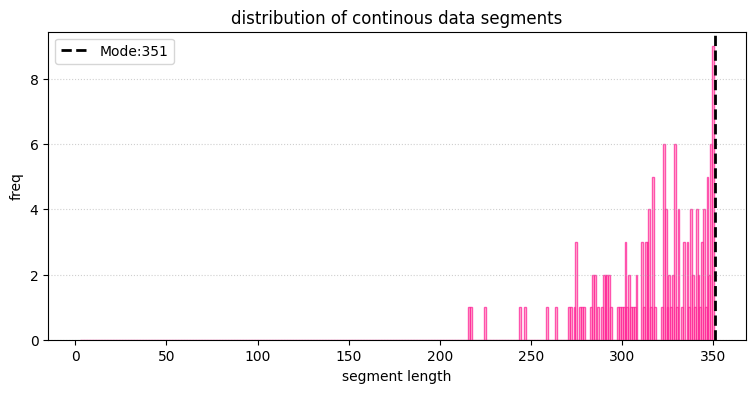

video of reconstruction
iteration done, moving to size 351
iteration 4, window size = 130
Training started for window size: 130 (train shape: (608, 130))
Epoch 1/30
38/38 [==============================] - 2s 29ms/step - loss: 0.0037 - val_loss: 1.7857e-04
Epoch 2/30
38/38 [==============================] - 1s 22ms/step - loss: 1.6307e-04 - val_loss: 1.0272e-04
Epoch 3/30
38/38 [==============================] - 1s 22ms/step - loss: 1.0633e-04 - val_loss: 9.5781e-05
Epoch 4/30
38/38 [==============================] - 1s 24ms/step - loss: 1.0191e-04 - val_loss: 5.5420e-05
Epoch 5/30
38/38 [==============================] - 1s 23ms/step - loss: 9.6597e-05 - val_loss: 5.8925e-05
Epoch 6/30
38/38 [==============================] - 1s 24ms/step - loss: 1.0519e-04 - val_loss: 6.8845e-05
Epoch 7/30
38/38 [==============================] - 1s 24ms/step - loss: 9.8018e-05 - val_loss: 6.1515e-05
Epoch 8/30
38/38 [==============================] - 1s 23ms/step - loss: 1.0932e-04 - val_loss: 4.374

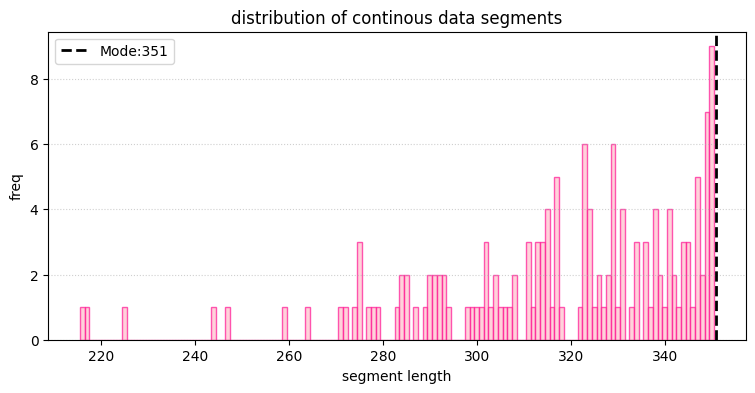

video of reconstruction
iteration done, moving to size 351
iteration 5, window size = 180
Training started for window size: 180 (train shape: (331, 180))
Epoch 1/30
20/20 [==============================] - 2s 37ms/step - loss: 0.0076 - val_loss: 8.1302e-04
Epoch 2/30
20/20 [==============================] - 1s 27ms/step - loss: 5.2989e-04 - val_loss: 6.2440e-04
Epoch 3/30
20/20 [==============================] - 1s 28ms/step - loss: 1.9561e-04 - val_loss: 1.5794e-04
Epoch 4/30
20/20 [==============================] - 1s 27ms/step - loss: 1.1744e-04 - val_loss: 9.4641e-05
Epoch 5/30
20/20 [==============================] - 1s 30ms/step - loss: 1.0531e-04 - val_loss: 4.1831e-05
Epoch 6/30
20/20 [==============================] - 1s 30ms/step - loss: 9.7014e-05 - val_loss: 3.3263e-05
Epoch 7/30
20/20 [==============================] - 1s 28ms/step - loss: 9.7151e-05 - val_loss: 3.2984e-05
Epoch 8/30
20/20 [==============================] - 1s 28ms/step - loss: 8.6894e-05 - val_loss: 3.457

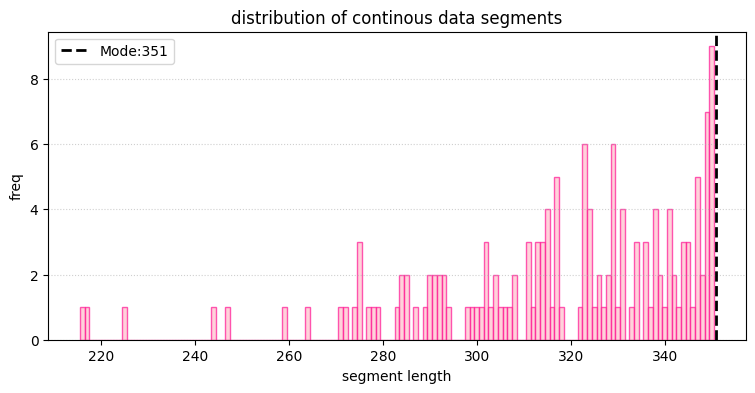

video of reconstruction
iteration done, moving to size 351
iteration 6, window size = 230
Training started for window size: 230 (train shape: (249, 230))
Epoch 1/30
15/15 [==============================] - 2s 45ms/step - loss: 0.0085 - val_loss: 0.0029
Epoch 2/30
15/15 [==============================] - 1s 38ms/step - loss: 9.9885e-04 - val_loss: 2.6840e-04
Epoch 3/30
15/15 [==============================] - 1s 38ms/step - loss: 3.4392e-04 - val_loss: 1.7800e-04
Epoch 4/30
15/15 [==============================] - 1s 39ms/step - loss: 1.6830e-04 - val_loss: 6.4847e-05
Epoch 5/30
15/15 [==============================] - 1s 39ms/step - loss: 1.3556e-04 - val_loss: 7.9330e-05
Epoch 6/30
15/15 [==============================] - 1s 41ms/step - loss: 1.1833e-04 - val_loss: 7.8743e-05
Epoch 7/30
15/15 [==============================] - 1s 36ms/step - loss: 1.0645e-04 - val_loss: 6.4016e-05
Epoch 8/30
15/15 [==============================] - 1s 37ms/step - loss: 1.0331e-04 - val_loss: 6.8382e-0

In [ ]:
# workflow using re-histogram method
#transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_73_nodune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)

historical_stages_zoo={}

total_iterations=6
current_window_size=10 # start size

pipeline_history={}
summary_stats=[]

for iteration in range(1,total_iterations+1):
    print(f"iteration {iteration}, window size = {current_window_size}")

    # index map of gaps
    current_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # train model
    trained_model,history,test_ds=run_MAE(window_size=current_window_size,df=current_dataset,split_windows_idx=current_windows_idx,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5) # testing not keeping previous recons
    # store results
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)

    #plot_reconstruction_matrix(current_df=current_dataset, active_mask_df=active_mask, filled_df=reconstructed_df, cmap='viridis', gap_color='deeppink')
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)
    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=1,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        elif current_mode>=current_window_size+50: #keep from too big of a jump forward
            current_window_size=int(current_window_size+50) 
        else:
            current_window_size=int(current_mode)


    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    #print("plotting static timesteps")
    #save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    

    print(f"iteration done, moving to size {current_mode}")


#final stats
current_dataset=current_dataset
active_mask=(~np.isnan(current_dataset)).astype(float)

historical_stages_zoo["stage_final"]=current_dataset
save_stage_video_animation(orig_full_df=transect_73,recon_no_dune_df=current_dataset,window_size=current_window_size,stage_dir=savepath,interval=500)


In [22]:
df=pd.concat([transect_73.iloc[:200],reconstructed_df],ignore_index=True)
#df_un_norm=denormalize(df)
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration1_transects_norm.csv",index=False)

ITERATION 2: One transect on either side

In [23]:
# QC training data (no values below zero)
train_ds[train_ds <0]=float('nan')
# normalize
#normalize training data

all_vals=train_ds.values.flatten()
all_vals=all_vals[~np.isnan(all_vals)]

min_elev=np.min(all_vals)
print("Minimum elev:", min_elev,"m")
max_elev=np.max(all_vals)
print("Max elev:", max_elev,"m")

#train_df_norm=(train_ds-min_elev)/(max_elev-min_elev)

Minimum elev: 0.449 m
Max elev: 10.141384615384617 m


In [56]:
#Grab transects closest to 7.3 for training
targets = ['transect_y4', 'transect_y9.3']
selected_transects = train_df_norm_nodune.query("transect_name in @targets")

In [57]:
print(selected_transects)

                                   0         1         2         3    \
transect_name original_index                                           
transect_y4   0               0.740339  0.740608       NaN  0.740965   
              1               0.741321  0.740608       NaN  0.740965   
              2               0.742303       NaN       NaN       NaN   
              3                    NaN       NaN       NaN       NaN   
              4                    NaN       NaN       NaN  0.739729   
...                                ...       ...       ...       ...   
transect_y9.3 546                  NaN  0.616189  0.616738  0.650455   
              547                  NaN  0.615955  0.617249  0.652691   
              548                  NaN       NaN  0.619418  0.654403   
              549             0.616507       NaN  0.622417  0.655192   
              550             0.616341  0.615730  0.625277  0.657057   

                                   4         5         6       

total windows found: 4675
shortest window: 1
longest window: 434


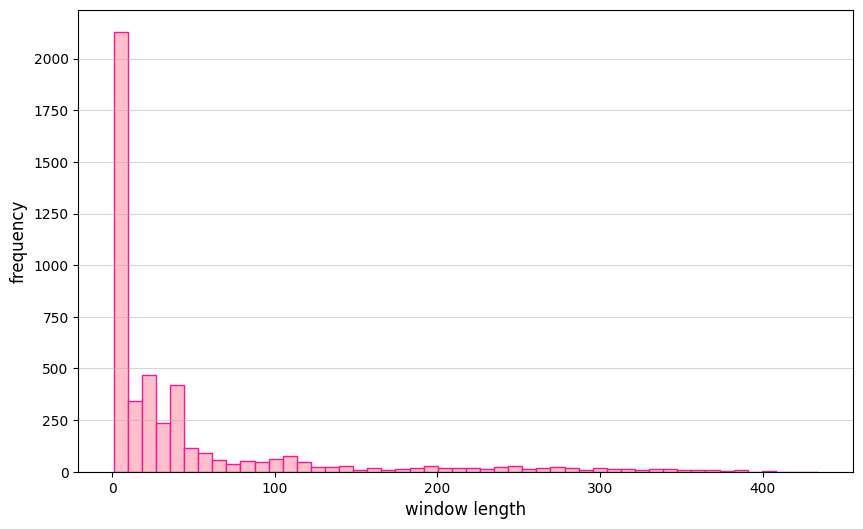

In [58]:
# find contnious windows of data for training ds
def what_window_sizes(df):
    lengths_per_col={}
    all_lengths=[]

    for col_name,col_data in df.items():
        arg=col_data.values
        masked=np.ma.masked_invalid(arg)
        clumps=np.ma.clump_unmasked(masked)

        lengths=[s.stop -s.start for s in clumps]
        lengths_per_col[col_name]=lengths
        all_lengths.extend(lengths)

    return lengths_per_col, all_lengths

lengths_by_col,total_lengths_list=what_window_sizes(selected_transects)

print(f"total windows found: {len(total_lengths_list)}")
print(f"shortest window: {np.min(total_lengths_list)}")
print(f"longest window: {np.max(total_lengths_list)}")

plt.figure(figsize=(10,6))

unique_lens=len(set(total_lengths_list))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(total_lengths_list,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.grid(axis="y",alpha=0.5)
plt.show()

    

In [59]:
from collections import Counter

filtered_lengths=[length for length in total_lengths_list if length>10]
length_counts=Counter(filtered_lengths)
top_five=length_counts.most_common(5)

for rank,(length,freq) in enumerate(top_five,1):
    print(f"{rank}. length: {length:<5} frequency: {freq:,}")


1. length: 21    frequency: 168
2. length: 38    frequency: 102
3. length: 39    frequency: 97
4. length: 22    frequency: 77
5. length: 20    frequency: 55


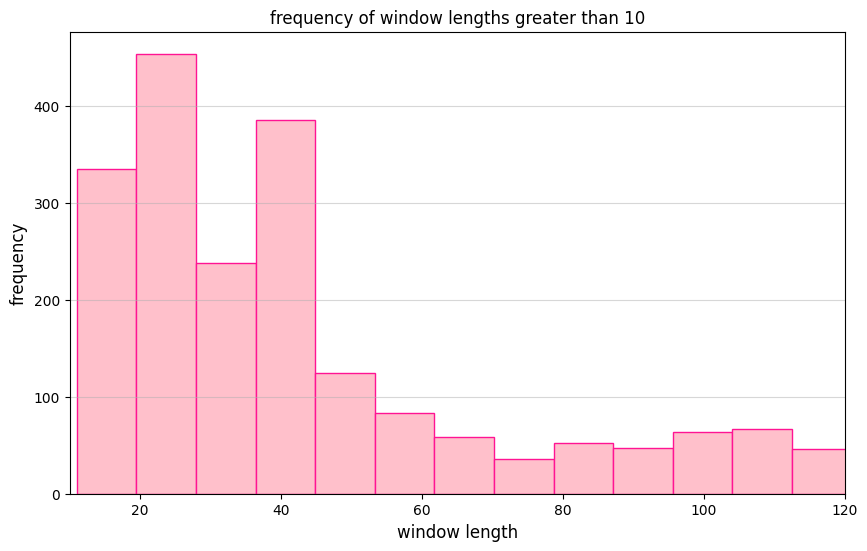

In [60]:
plt.figure(figsize=(10,6))

unique_lens=len(set(filtered_lengths))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(filtered_lengths,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.title("frequency of window lengths greater than 10")
plt.grid(axis="y",alpha=0.5)
plt.xlim(10,120)
plt.show()

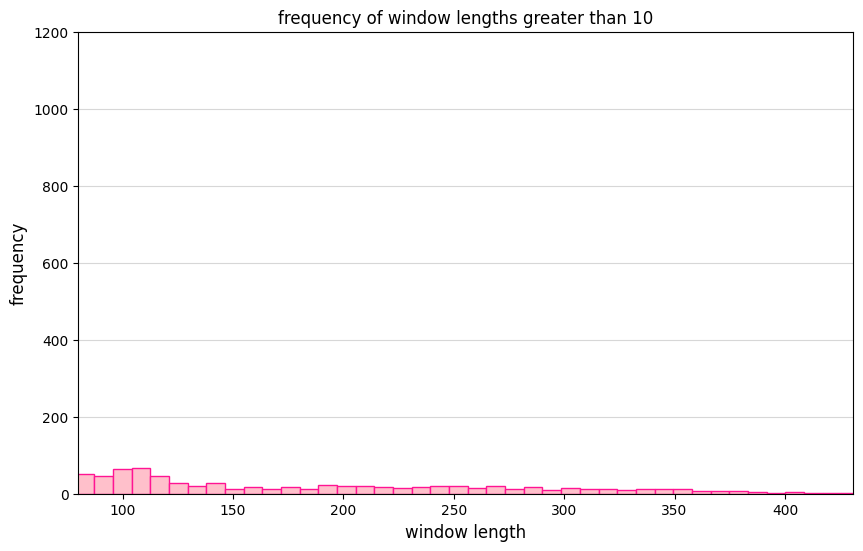

In [61]:
plt.figure(figsize=(10,6))

unique_lens=len(set(filtered_lengths))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(filtered_lengths,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.title("frequency of window lengths greater than 10")
plt.grid(axis="y",alpha=0.5)
plt.ylim(0,1200)
plt.xlim(80,431)
plt.show()

Define model and functions

In [41]:
def prep_training(train_source_df,split_windows_idx,batch_size=16):
    # windows of training/testing/vaidation data
    # run MAE training cycle per targeted window size
    timesteps=sorted(split_windows_idx.keys()) #chronological order
    n=len(timesteps)

    # train/val/test bounds
    train_end=int(n*0.7)
    val_end=int(n*0.85)

    train_time=timesteps[:train_end] #slice to grab train/test/val
    val_time=timesteps[train_end:val_end]
    test_time=timesteps[val_end:]

    def grab_windows(time_list): #loop through list of timesteps grab columnmand store as numpy vector
        X, info = [],[]
        for t in time_list:
            transect=train_source_df[t].values #grab from static training source
            
            for (start,stop) in split_windows_idx[t]: # windows of chosen size
                X.append(transect[start:stop])
                info.append({'timestep':t,'start':start,'stop':stop}) # store location to put back together
        return np.array(X, dtype="float32"), info
    
    X_train, info_train=grab_windows(train_time)
    X_val, info_val=grab_windows(val_time)
    X_test, info_test=grab_windows(test_time)

    # create ds function (mem efficient)
    def build_ds(X,info):
        starts=np.array([i['start'] for i in info]) # start points spatial
        tsteps=np.array([i['timestep'] for i in info]) # end points spatial
        ds=tf.data.Dataset.from_tensor_slices((X,starts,tsteps)) # arrays into TensorFlow tensor slice ds
        # mask over transect windows, process masks concureently, batches of 16, prep batch n+1 while working on current batch (efficiency)
        return (ds.map(masking_layer,num_parallel_calls=tf.data.AUTOTUNE).batch(batch_size,drop_remainder=True).prefetch(tf.data.AUTOTUNE))
    
    train_ds=build_ds(X_train,info_train)
    test_ds=build_ds(X_test,info_test)
    val_ds=build_ds(X_val,info_val)

    return train_ds, test_ds, val_ds

In [42]:
from tensorflow.keras.optimizers import Adam

In [43]:
def run_MAE(window_size,train_ds,val_ds, epochs=20):
    # inirialize model
    model=Denoise(window_size=window_size)
    #optimizer_tuned=Adam(learning_rate=1e-4)
    model.compile(optimizer='adam')

    #print(f"Training started for window size: {window_size} (train shape: {train_ds.shape})")
    history=model.fit(train_ds, validation_data=val_ds, epochs=epochs, verbose=1)
    return model, history

In [44]:
def reconstruct_ds_with_MAE(model, current_df, active_mask_df, window_size, stride=5):
    # slides MAE over the transects from left to right to impute where gaps exist
    # returns newly filled dataset
    x_matrix=tf.convert_to_tensor(current_df.values,dtype=tf.float32) # dataframe to tensorflow float 32
    transect_pts,tsteps=x_matrix.shape # length or cross-shore, timesteps

    mask_matrix=active_mask_df.values.astype(np.float32)
    #raw_groundtruth=baseline_raw_df.values

    reconstructed_all=[]

    for i in range(tsteps): # loop through every time step
        x_1dim=x_matrix[:,i].numpy() #current transect
        mask_1dim=mask_matrix[:,i] #gaps present in og or prev reconstrcution
        #raw_1dim=raw_groundtruth[:,i] #true og data

        full_recon=np.zeros_like(x_1dim) 
        counts=np.zeros_like(x_1dim)

        # slide window over full transect profile
        for start in range(0,transect_pts-window_size+1,stride):
            end=start+window_size

            #window_raw=raw_1dim[start:end] # window of raw data
            window_data=np.nan_to_num(x_1dim[start:end]) #slice of transect any nans to 0 current df
            window_mask=mask_1dim[start:end] #

            #model input shape
            combined_input=np.stack([window_data,window_mask],axis=-1).reshape(1,window_size,2) # transect slice with batch dim

            # check for too big of gap
            gap_too_big=is_gap_too_big(window_mask,window_size) 
            # check if window is full
            is_already_full = np.all(window_mask == 1.0)
            # check if the window has valid data on left and right edges
            has_bounded_edges = (window_mask[0] == 1.0) and (window_mask[-1] == 1.0)
            #double check there actually is a gap inside to fix (at least 1 point)
            has_gap_inside = np.any(window_mask == 0.0)

            # run MAE only if it's bounded on both sides
            if has_gap_inside and has_bounded_edges:
                #predict with MAE
                model_recon = model.predict(combined_input, verbose=0).flatten()
                # keep original data
                recon_window=np.where(window_mask==1.0,window_data,model_recon) # keep og data

                #preds for avg
                full_recon[start:end] = np.nansum([full_recon[start:end], recon_window], axis=0)
                counts[start:end] += 1
            
            elif is_already_full:
                #keep full window
                full_recon[start:end] = np.nansum([full_recon[start:end], window_data], axis=0)
                counts[start:end] += 1
        # trying to fix mismatch on gap edges
        raw_prediction=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0)
        nan_indices=np.isnan(raw_prediction)
        raw_prediction[nan_indices]=x_1dim[nan_indices]

        final_transect=raw_prediction.copy()
        is_gap=(mask_1dim==0) # find gap
        gap_changes=np.diff(is_gap.astype(int))

        gap_starts=np.where(gap_changes==1)[0]+1
        gap_ends=np.where(gap_changes==-1)[0]

        # at the edge
        if is_gap[0]: gap_starts= np.insert(gap_starts,0,0)
        if is_gap[-1]: gap_ends=np.append(gap_ends,len(is_gap)-1)
        # smooth over transistion?
        blend_zone=min(4,int(window_size/4)) # transistion blending margin

        for g_start,g_end in zip(gap_starts,gap_ends):
            #left side blend
            if g_start>blend_zone:
                anchor_val=x_1dim[g_start -1] #known real value
                for b in range(blend_zone):
                    idx=g_start+b
                    if idx<= g_end:
                        # linear transition (Could do something better) from anchor to pred
                        alpha=(b+1)/(blend_zone +1)
                        final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]
            #right side
            if g_end< len(x_1dim)-blend_zone:
                anchor_val=x_1dim[g_end+1]
                for b in range(blend_zone):
                    idx=g_end-b
                    if idx>=g_start:
                        alpha=(b+1)/(blend_zone+1)
                        final_transect[idx]=(1-alpha)*anchor_val+alpha*raw_prediction[idx]


        # avg overlapping windows
        #final_transect=np.divide(full_recon,counts,out=np.full_like(full_recon,np.nan),where=counts>0)
        # keep anything if skipped
        #nan_indices=np.isnan(final_transect)
        #final_transect[nan_indices]=x_1dim[nan_indices]

        # overide to keep og data
        final_transect=np.where(mask_1dim==1.0,x_1dim,final_transect)

        reconstructed_all.append(final_transect)
    # return dataframe (points, timesteps)
    return pd.DataFrame(np.stack(reconstructed_all,axis=1),columns=current_df.columns)


In [45]:
def window_split(start,stop,size,overlap):
    return[(i,i+size) for i in range(start,stop-size+1,int(overlap))]

In [46]:
def find_windows_of_data(df,window_size,overlap_stride):
    # find the continous sections of data and extract window indices
    window_idx={}
    for timestep,transect in df.items():
        arg=transect.values
        masked=np.ma.masked_invalid(arg)
        clumps=np.ma.clump_unmasked(masked)
        window_idx[timestep]=[(s.start,s.stop)for s in clumps]

    split_windows_idx={}
    for timestep in window_idx:
        new_windows=[]
        for (start,stop) in window_idx[timestep]:
            length=stop-start
            if length>= window_size:
                new_windows.extend(window_split(start,stop,window_size,overlap_stride))
        split_windows_idx[timestep]=new_windows

    return split_windows_idx


In [47]:
from collections import Counter
def reeval_and_hist(active_mask_df,min_length,target_val=0,plot_histogram=True,stage_label=""):
    # functiin to histogram after reconstruction
    mask_matrix=active_mask_df.values
    spatial_pts,tsteps=mask_matrix.shape
    all_window_lengths=[]

    for col in range(tsteps):
        column=mask_matrix[:,col]
        is_target=(column==target_val) # find zeros
        # pad edges to get everything
        bound=np.hstack(([False],is_target,[False]))
        diffs=np.diff(bound.astype(int))

        starts=np.where(diffs==1)[0]
        ends=np.where(diffs==-1)[0]
        lengths=ends-starts

        all_window_lengths.extend(lengths)

    filtered_lengths=[l for l in all_window_lengths if l>=min_length]

    freq_map=Counter(filtered_lengths)
    mode_size=freq_map.most_common(1)[0][0]

    print(f"mode: {mode_size}")
    print(f"max length: {max(filtered_lengths)}")
    print(f"min length: {min(filtered_lengths)}")

    if plot_histogram:
        plt.figure(figsize=(9,4))
        plt.hist(filtered_lengths,bins=np.arange(min(all_window_lengths)-0.5, max(all_window_lengths)+0.5,1),color='pink',edgecolor='deeppink',alpha=0.7)
        plt.axvline(mode_size,color='black',linestyle='--',linewidth=2,label=f'Mode:{mode_size}')
        plt.title(f'distribution of continous data segments')
        plt.xlabel('segment length')
        plt.ylabel('freq')
        plt.legend()
        plt.grid(axis='y',linestyle=':',alpha=0.6)
        plt.show()

        return mode_size


In [48]:
def save_stage_video_animation(orig_full_df, recon_no_dune_df, window_size, stage_dir="stage_outputs", interval=500):
    """
    Creates and saves a dynamic video tracking profile repairs over time,
    maintaining the unedited dune profile on the left.
    """
    os.makedirs(stage_dir, exist_ok=True)
   
    DUNE_OFFSET = 200
    orig_full_data = orig_full_df.values
    recon_no_dune_data = recon_no_dune_df.values
   
    n_points, n_timesteps = orig_full_data.shape
    x_coords = np.arange(n_points)

    fig, ax = plt.subplots(figsize=(12, 5))
   
    # Set standard layout constraints based on full dataset limits
    ax.set_xlim(0, n_points)
    ax.set_ylim(np.nanmin(orig_full_data) - 0.1, np.nanmax(orig_full_data) + 0.1)
    ax.set_xlabel("Full Cross-shore index")
    ax.set_ylabel("Normalized Elevation")
   
    # Initialize baseline handles
    line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
    line_orig, = ax.plot([], [], color='blue', alpha=0.6, label='Original Survey (with Dune)')
    #line_recon, = ax.plot([], [], color='deeppink', linewidth=2, label=f'MAE-{window_size} Active Pass')
   
    # Draw static divider indicator
    ax.axvline(x=DUNE_OFFSET, color='black', linestyle=':', alpha=0.4)
    ax.legend(loc='lower left')

    # gaps as highlights
    gap_spans=[]
    gap_patch=plt.Rectangle((0,0),1,1,fc="gray", alpha=0.3,label='gaps')
    ax.legend(handles=[line_orig,line_recon,gap_patch],loc='lower left')

    def update(frame):
        nonlocal gap_spans
        for span in gap_spans:
            span.remove()
        gap_spans.clear()
        y_orig = orig_full_data[:, frame]
       
        # Stitch the original dune to the model's currently filled lower beach
        y_recon_full = y_orig.copy()
        y_recon_full[DUNE_OFFSET:] = recon_no_dune_data[:, frame]

        is_gap=np.isnan(y_orig)
        is_gap[:DUNE_OFFSET]=False #ignore gaps in dune

        if np.any(is_gap):
            diff=np.diff(is_gap.astype(int))
            gap_starts=np.where(diff==1)[0]+1
            gap_ends=np.where(diff==-1)[0]+1

            if is_gap[0]:
                gap_starts=np.insert(gap_starts,0,0)
            if is_gap[-1]:
                gap_ends=np.append(gap_ends,n_points-1)

            for start,end in zip(gap_starts, gap_ends):
                span=ax.axvspan(start,end,color='gray',alpha=0.25,zorder=0)
                gap_spans.append(span)

       
        line_recon.set_data(x_coords, y_recon_full)
        line_orig.set_data(x_coords, y_orig)
        #line_recon.set_data(x_coords, y_recon_full)
       
        ax.set_title(f"Full Reconstruction | Stage: MAE-{window_size} | Timestep: {frame}")
        return [line_orig, line_recon] + gap_spans

    anim = FuncAnimation(fig, update, frames=n_timesteps, interval=interval, blit=True)
   
    video_path = os.path.join(stage_dir, f"full_profile_stage_MAE{window_size}.gif")
    anim.save(video_path, writer="pillow")
    plt.close()

Train and run MAE

In [49]:
def unscale_dataframe(df,fitted_scalar):
    matrix=df.values.copy()
    flat_vals=matrix.reshape(-1,1)
    non_nan_mask=~np.isnan(flat_vals)
    # reverse scaling
    flat_vals[non_nan_mask]=fitted_scalar.inverse_transform(flat_vals[non_nan_mask].reshape(-1,1)).flatten()
    unscaled_df=pd.DataFrame(flat_vals.reshape(df.shape),columns=df.columns,index=df.index)
    return unscaled_df

Epoch 1/30
1609/1609 [==============================] - 30s 18ms/step - loss: 8.5826e-04 - val_loss: 6.7819e-05
Epoch 2/30
1609/1609 [==============================] - 29s 18ms/step - loss: 1.2268e-04 - val_loss: 5.9277e-05
Epoch 3/30
1609/1609 [==============================] - 29s 18ms/step - loss: 1.0443e-04 - val_loss: 5.8390e-05
Epoch 4/30
1609/1609 [==============================] - 29s 18ms/step - loss: 9.6155e-05 - val_loss: 1.8997e-05
Epoch 5/30
1609/1609 [==============================] - 30s 18ms/step - loss: 5.3947e-05 - val_loss: 5.1503e-05
Epoch 6/30
1609/1609 [==============================] - 30s 18ms/step - loss: 9.3605e-05 - val_loss: 2.4172e-05
Epoch 7/30
1609/1609 [==============================] - 29s 18ms/step - loss: 6.5802e-05 - val_loss: 3.0852e-05
Epoch 8/30
1609/1609 [==============================] - 29s 18ms/step - loss: 6.5226e-05 - val_loss: 6.6663e-06
Epoch 9/30
1609/1609 [==============================] - 29s 18ms/step - loss: 6.8571e-05 - val_loss: 4.6

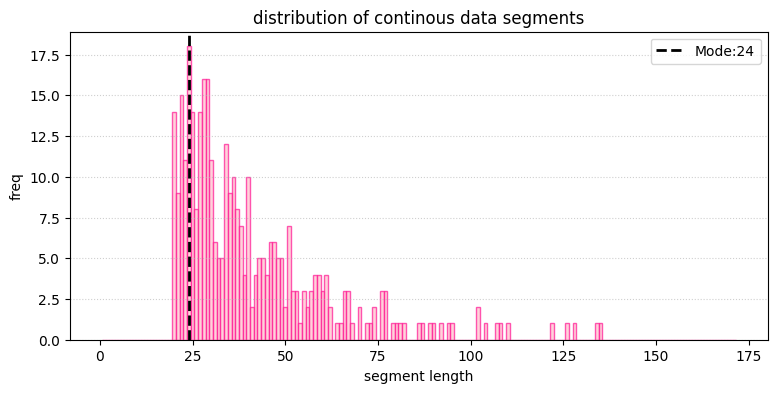

iteration done, moving to size 24
Epoch 1/30
576/576 [==============================] - 13s 20ms/step - loss: 9.8510e-04 - val_loss: 1.8394e-04
Epoch 2/30
576/576 [==============================] - 11s 20ms/step - loss: 1.1038e-04 - val_loss: 1.0730e-05
Epoch 3/30
576/576 [==============================] - 11s 20ms/step - loss: 9.1231e-05 - val_loss: 1.4288e-05
Epoch 4/30
576/576 [==============================] - 11s 20ms/step - loss: 9.0634e-05 - val_loss: 3.1544e-05
Epoch 5/30
576/576 [==============================] - 12s 20ms/step - loss: 8.9449e-05 - val_loss: 2.6357e-05
Epoch 6/30
576/576 [==============================] - 11s 20ms/step - loss: 7.6833e-05 - val_loss: 3.2419e-05
Epoch 7/30
576/576 [==============================] - 11s 20ms/step - loss: 7.7983e-05 - val_loss: 6.7347e-05
Epoch 8/30
576/576 [==============================] - 11s 20ms/step - loss: 6.1071e-05 - val_loss: 7.3876e-06
Epoch 9/30
576/576 [==============================] - 11s 19ms/step - loss: 9.2605e-05

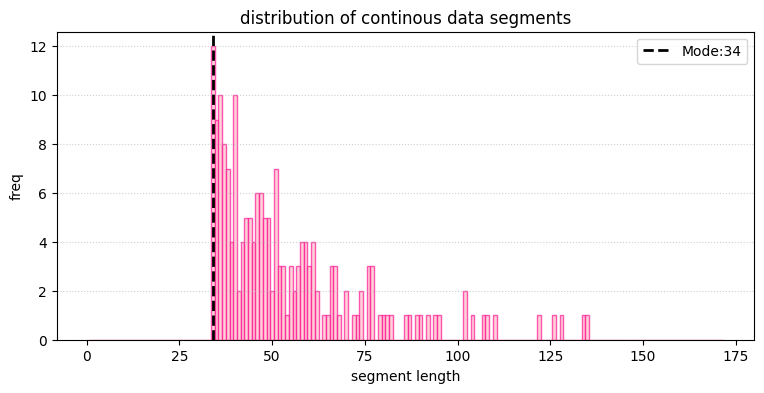

iteration done, moving to size 34
Epoch 1/30
371/371 [==============================] - 5s 10ms/step - loss: 0.0012 - val_loss: 2.1223e-04
Epoch 2/30
371/371 [==============================] - 3s 9ms/step - loss: 4.8911e-04 - val_loss: 1.4441e-04
Epoch 3/30
371/371 [==============================] - 4s 10ms/step - loss: 2.2934e-04 - val_loss: 2.0170e-04
Epoch 4/30
371/371 [==============================] - 3s 9ms/step - loss: 1.1805e-04 - val_loss: 8.9536e-05
Epoch 5/30
371/371 [==============================] - 3s 9ms/step - loss: 9.8051e-05 - val_loss: 3.1523e-05
Epoch 6/30
371/371 [==============================] - 3s 9ms/step - loss: 1.2824e-04 - val_loss: 4.7175e-05
Epoch 7/30
371/371 [==============================] - 4s 10ms/step - loss: 1.0311e-04 - val_loss: 5.4073e-05
Epoch 8/30
371/371 [==============================] - 4s 10ms/step - loss: 1.0003e-04 - val_loss: 2.1195e-05
Epoch 9/30
371/371 [==============================] - 4s 10ms/step - loss: 7.7372e-05 - val_loss: 8.86

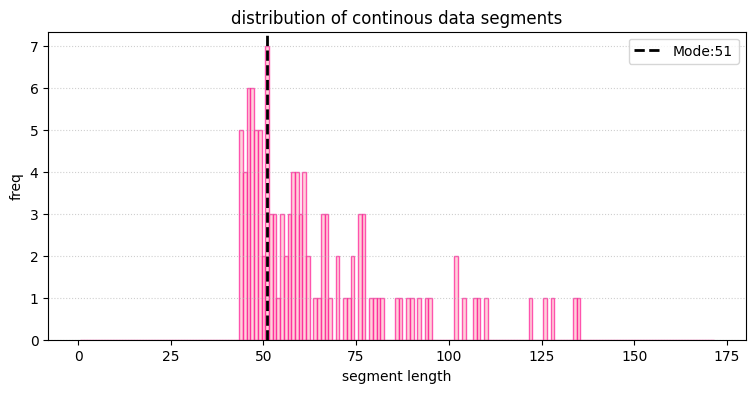

iteration done, moving to size 51
Epoch 1/30
215/215 [==============================] - 3s 10ms/step - loss: 0.0010 - val_loss: 2.6166e-04
Epoch 2/30
215/215 [==============================] - 2s 9ms/step - loss: 2.3712e-04 - val_loss: 2.1016e-04
Epoch 3/30
215/215 [==============================] - 2s 9ms/step - loss: 2.4089e-04 - val_loss: 1.7545e-04
Epoch 4/30
215/215 [==============================] - 2s 9ms/step - loss: 2.3057e-04 - val_loss: 1.9762e-04
Epoch 5/30
215/215 [==============================] - 2s 8ms/step - loss: 2.6160e-04 - val_loss: 2.0079e-04
Epoch 6/30
215/215 [==============================] - 2s 9ms/step - loss: 2.7258e-04 - val_loss: 2.3546e-04
Epoch 7/30
215/215 [==============================] - 2s 9ms/step - loss: 2.3373e-04 - val_loss: 2.3587e-04
Epoch 8/30
215/215 [==============================] - 2s 9ms/step - loss: 2.4964e-04 - val_loss: 1.0680e-04
Epoch 9/30
215/215 [==============================] - 2s 9ms/step - loss: 1.9685e-04 - val_loss: 5.7824e-

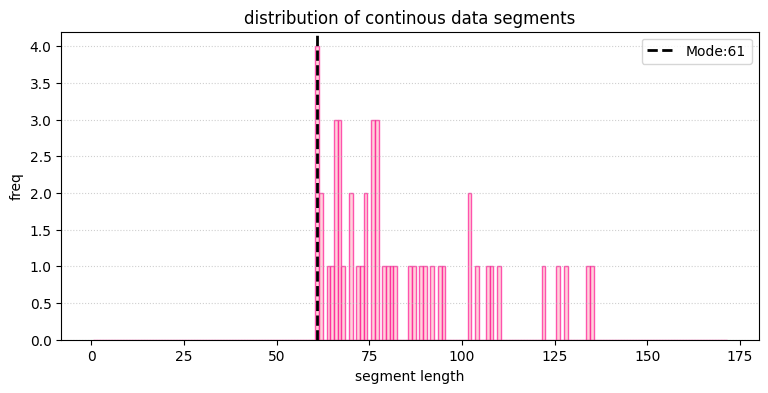

iteration done, moving to size 61
Epoch 1/30
167/167 [==============================] - 3s 13ms/step - loss: 0.0016 - val_loss: 2.3499e-04
Epoch 2/30
167/167 [==============================] - 2s 12ms/step - loss: 2.2430e-04 - val_loss: 3.1020e-04
Epoch 3/30
167/167 [==============================] - 2s 12ms/step - loss: 2.2828e-04 - val_loss: 2.5261e-04
Epoch 4/30
167/167 [==============================] - 2s 13ms/step - loss: 2.1578e-04 - val_loss: 3.8329e-04
Epoch 5/30
167/167 [==============================] - 2s 11ms/step - loss: 2.4576e-04 - val_loss: 2.6684e-04
Epoch 6/30
167/167 [==============================] - 2s 11ms/step - loss: 2.5175e-04 - val_loss: 3.2639e-04
Epoch 7/30
167/167 [==============================] - 2s 12ms/step - loss: 2.4408e-04 - val_loss: 3.0347e-04
Epoch 8/30
167/167 [==============================] - 2s 13ms/step - loss: 2.5699e-04 - val_loss: 2.1502e-04
Epoch 9/30
167/167 [==============================] - 2s 12ms/step - loss: 2.4964e-04 - val_loss: 

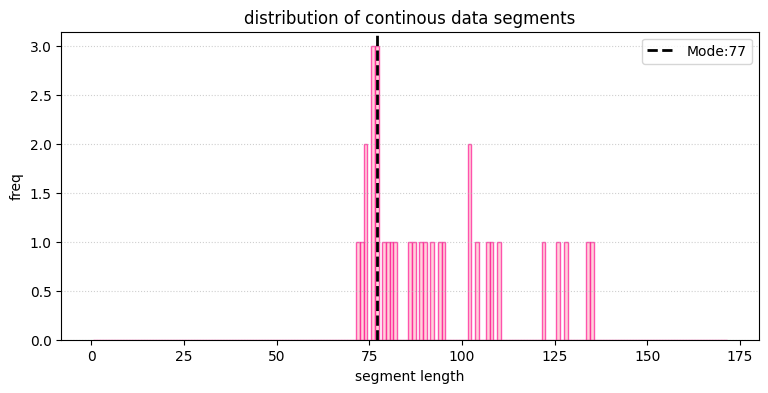

iteration done, moving to size 77
Epoch 1/30
118/118 [==============================] - 3s 18ms/step - loss: 0.0021 - val_loss: 2.1915e-04
Epoch 2/30
118/118 [==============================] - 1s 12ms/step - loss: 2.5668e-04 - val_loss: 2.2984e-04
Epoch 3/30
118/118 [==============================] - 1s 11ms/step - loss: 2.3791e-04 - val_loss: 2.5445e-04
Epoch 4/30
118/118 [==============================] - 1s 11ms/step - loss: 2.6853e-04 - val_loss: 2.2043e-04
Epoch 5/30
118/118 [==============================] - 1s 10ms/step - loss: 2.6233e-04 - val_loss: 2.7018e-04
Epoch 6/30
118/118 [==============================] - 1s 11ms/step - loss: 2.5142e-04 - val_loss: 2.0451e-04
Epoch 7/30
118/118 [==============================] - 1s 11ms/step - loss: 2.8466e-04 - val_loss: 3.0187e-04
Epoch 8/30
118/118 [==============================] - 1s 11ms/step - loss: 2.2768e-04 - val_loss: 2.1660e-04
Epoch 9/30
118/118 [==============================] - 1s 11ms/step - loss: 2.5055e-04 - val_loss: 

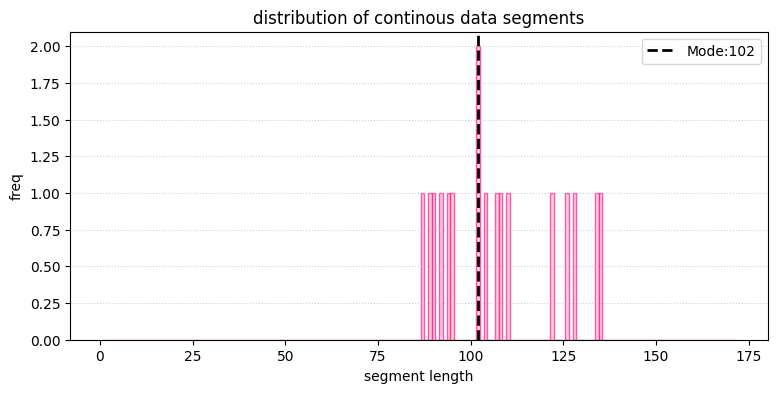

iteration done, moving to size 102
Epoch 1/30
75/75 [==============================] - 2s 16ms/step - loss: 0.0024 - val_loss: 2.6117e-04
Epoch 2/30
75/75 [==============================] - 1s 14ms/step - loss: 2.2748e-04 - val_loss: 2.5624e-04
Epoch 3/30
75/75 [==============================] - 1s 14ms/step - loss: 2.3837e-04 - val_loss: 3.0894e-04
Epoch 4/30
75/75 [==============================] - 1s 15ms/step - loss: 2.5966e-04 - val_loss: 1.8104e-04
Epoch 5/30
75/75 [==============================] - 1s 14ms/step - loss: 2.3675e-04 - val_loss: 1.9360e-04
Epoch 6/30
75/75 [==============================] - 1s 14ms/step - loss: 2.4813e-04 - val_loss: 1.9359e-04
Epoch 7/30
75/75 [==============================] - 1s 14ms/step - loss: 2.4614e-04 - val_loss: 1.8137e-04
Epoch 8/30
75/75 [==============================] - 1s 13ms/step - loss: 2.1745e-04 - val_loss: 1.6487e-04
Epoch 9/30
75/75 [==============================] - 1s 14ms/step - loss: 2.3255e-04 - val_loss: 1.4742e-04
Epoch 

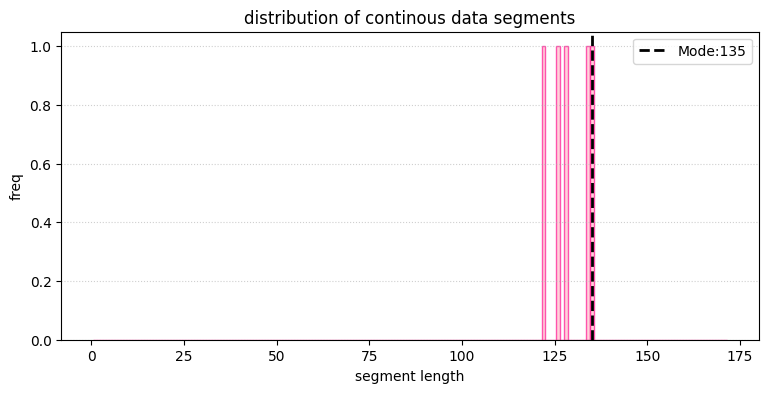

iteration done, moving to size 135
Epoch 1/30
45/45 [==============================] - 2s 26ms/step - loss: 0.0051 - val_loss: 2.5888e-04
Epoch 2/30
45/45 [==============================] - 1s 24ms/step - loss: 1.9374e-04 - val_loss: 2.7977e-04
Epoch 3/30
45/45 [==============================] - 1s 22ms/step - loss: 2.3837e-04 - val_loss: 2.3435e-04
Epoch 4/30
45/45 [==============================] - 1s 22ms/step - loss: 2.2980e-04 - val_loss: 1.8977e-04
Epoch 5/30
45/45 [==============================] - 1s 24ms/step - loss: 2.3583e-04 - val_loss: 1.7423e-04
Epoch 6/30
45/45 [==============================] - 1s 24ms/step - loss: 2.1702e-04 - val_loss: 2.3006e-04
Epoch 7/30
45/45 [==============================] - 1s 23ms/step - loss: 2.1975e-04 - val_loss: 1.8095e-04
Epoch 8/30
45/45 [==============================] - 1s 23ms/step - loss: 2.2686e-04 - val_loss: 1.9380e-04
Epoch 9/30
45/45 [==============================] - 1s 23ms/step - loss: 2.2145e-04 - val_loss: 1.9679e-04
Epoch 

In [62]:
# updated method with training data from alongshore transects
savepath=r'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/L2R_results_prelim/building_upL2R/iteration2'
# grabbing transect for predictions
#transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_73_nodune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)
training_ds=selected_transects.copy() # this is no dune
# starting vars
historical_stages_zoo={}
total_iterations=8
current_window_size=10 # start size
pipeline_history={}
summary_stats=[]

for iteration in range (1,total_iterations+1):
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size/2))# need for metrics (where are gaps)
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)

    # unscale data for plotting
    #recon_phys_df=unscale_dataframe(reconstructed_df,global_scaler)
    #orig_phys_df=transect_df_raw.copy()
    #recon_phys_df[original_baseline_no_dune.isna()]=np.nan
    
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    #save_stage_gaps_video_animation(orig_full_df=train_df_norm,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)

    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")
    


In [63]:
df=pd.concat([transect_73.iloc[:200],reconstructed_df],ignore_index=True)
#df_un_norm=denormalize(df)
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration2_transects_norm.csv",index=False)

ITERATION 3: 5 Transects on either side of transect 7.3


In [64]:
#Grab transects closest to 7.3 for training
targets = ['transect_y4', 'transect_y9.3','transect_y2','transect_y0','transect_y-2','transect_y-4','transect_y12.3','transect_y15.3','transect_y18.3','transect_y21.3']
selected_transects = train_df_norm_nodune.query("transect_name in @targets")
print(selected_transects)

                               0    1    2    3    4    5    6    7    8    \
transect_name  original_index                                                
transect_y-4   0               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               1               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               2               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               3               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               4               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
...                            ...  ...  ...  ...  ...  ...  ...  ...  ...   
transect_y21.3 546             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               547             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               548             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               549             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               550             NaN  NaN  NaN  NaN  NaN  NaN  NaN

total windows found: 21900
shortest window: 1
longest window: 434


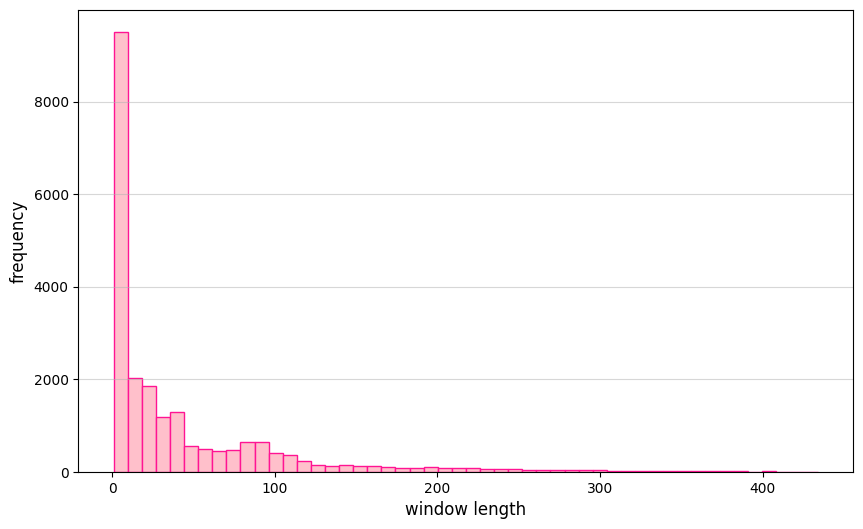

1. length: 25    frequency: 321
2. length: 12    frequency: 301
3. length: 21    frequency: 297
4. length: 38    frequency: 273
5. length: 22    frequency: 256


In [65]:
lengths_by_col,total_lengths_list=what_window_sizes(selected_transects)

print(f"total windows found: {len(total_lengths_list)}")
print(f"shortest window: {np.min(total_lengths_list)}")
print(f"longest window: {np.max(total_lengths_list)}")

plt.figure(figsize=(10,6))

unique_lens=len(set(total_lengths_list))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(total_lengths_list,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.grid(axis="y",alpha=0.5)
plt.show()

filtered_lengths=[length for length in total_lengths_list if length>10]
length_counts=Counter(filtered_lengths)
top_five=length_counts.most_common(5)

for rank,(length,freq) in enumerate(top_five,1):
    print(f"{rank}. length: {length:<5} frequency: {freq:,}")


Epoch 1/30
6698/6698 [==============================] - 126s 19ms/step - loss: 2.3745e-04 - val_loss: 4.0192e-05
Epoch 2/30
6698/6698 [==============================] - 133s 20ms/step - loss: 3.4689e-05 - val_loss: 1.6382e-05
Epoch 3/30
6698/6698 [==============================] - 122s 18ms/step - loss: 3.7071e-05 - val_loss: 3.5557e-06
Epoch 4/30
6698/6698 [==============================] - 110s 16ms/step - loss: 3.1026e-05 - val_loss: 4.1567e-06
Epoch 5/30
6698/6698 [==============================] - 106s 16ms/step - loss: 3.7036e-05 - val_loss: 5.4958e-06
Epoch 6/30
6698/6698 [==============================] - 113s 17ms/step - loss: 2.6849e-05 - val_loss: 6.0898e-06
Epoch 7/30
6698/6698 [==============================] - 112s 17ms/step - loss: 2.7768e-05 - val_loss: 5.7390e-06
Epoch 8/30
6698/6698 [==============================] - 106s 16ms/step - loss: 3.2599e-05 - val_loss: 3.3751e-06
Epoch 9/30
6698/6698 [==============================] - 102s 15ms/step - loss: 2.4959e-05 - val_

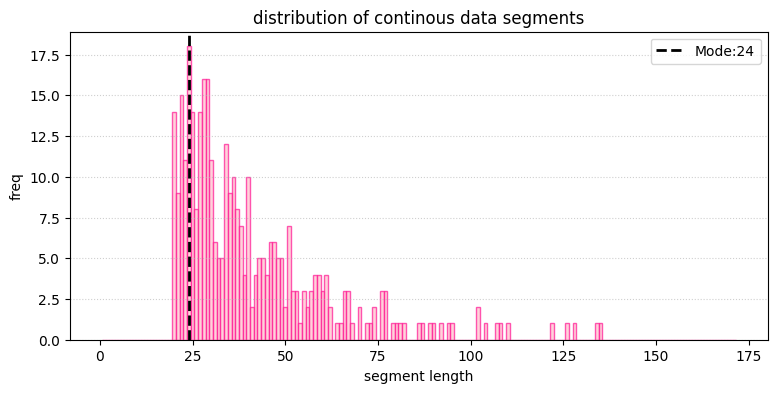

iteration done, moving to size 24
Epoch 1/30
2345/2345 [==============================] - 39s 16ms/step - loss: 4.4793e-04 - val_loss: 1.9455e-05
Epoch 2/30
2345/2345 [==============================] - 39s 17ms/step - loss: 6.1504e-05 - val_loss: 2.4978e-05
Epoch 3/30
2345/2345 [==============================] - 41s 17ms/step - loss: 5.0620e-05 - val_loss: 8.2174e-06
Epoch 4/30
2345/2345 [==============================] - 41s 17ms/step - loss: 4.1672e-05 - val_loss: 6.5053e-06
Epoch 5/30
2345/2345 [==============================] - 41s 17ms/step - loss: 3.4881e-05 - val_loss: 1.1879e-05
Epoch 6/30
2345/2345 [==============================] - 42s 18ms/step - loss: 3.7751e-05 - val_loss: 6.8078e-06
Epoch 7/30
2345/2345 [==============================] - 43s 18ms/step - loss: 2.5167e-05 - val_loss: 3.5765e-06
Epoch 8/30
2345/2345 [==============================] - 43s 18ms/step - loss: 2.9370e-05 - val_loss: 2.3065e-05
Epoch 9/30
2345/2345 [==============================] - 43s 18ms/step 

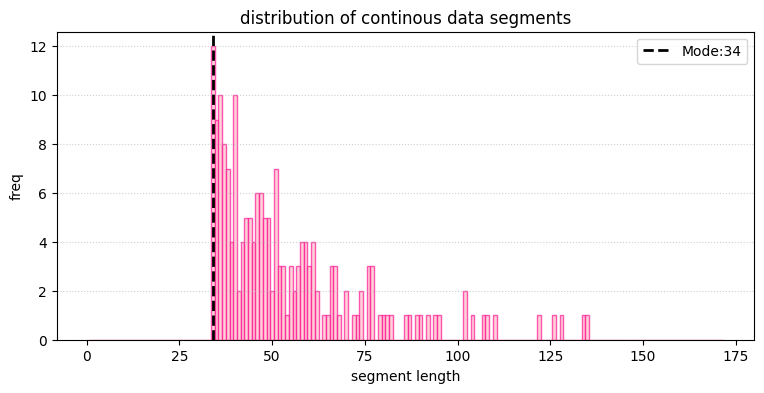

iteration done, moving to size 34
Epoch 1/30
1472/1472 [==============================] - 14s 9ms/step - loss: 5.6930e-04 - val_loss: 1.7544e-04
Epoch 2/30
1472/1472 [==============================] - 12s 8ms/step - loss: 1.1926e-04 - val_loss: 9.6157e-05
Epoch 3/30
1472/1472 [==============================] - 13s 9ms/step - loss: 6.3480e-05 - val_loss: 2.3917e-05
Epoch 4/30
1472/1472 [==============================] - 13s 9ms/step - loss: 5.5613e-05 - val_loss: 2.0822e-05
Epoch 5/30
1472/1472 [==============================] - 12s 8ms/step - loss: 4.1391e-05 - val_loss: 1.7588e-05
Epoch 6/30
1472/1472 [==============================] - 13s 9ms/step - loss: 3.7424e-05 - val_loss: 1.3355e-05
Epoch 7/30
1472/1472 [==============================] - 13s 9ms/step - loss: 4.0169e-05 - val_loss: 1.5523e-05
Epoch 8/30
1472/1472 [==============================] - 13s 9ms/step - loss: 5.0283e-05 - val_loss: 1.0253e-05
Epoch 9/30
1472/1472 [==============================] - 13s 9ms/step - loss: 3

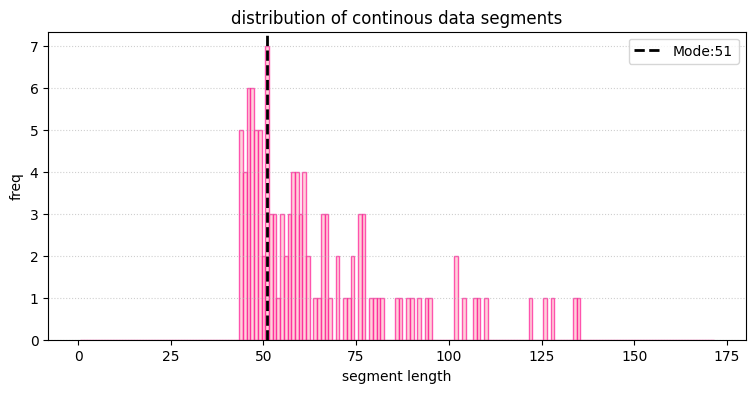

iteration done, moving to size 51
Epoch 1/30
820/820 [==============================] - 9s 9ms/step - loss: 5.1229e-04 - val_loss: 4.1095e-04
Epoch 2/30
820/820 [==============================] - 8s 9ms/step - loss: 1.6078e-04 - val_loss: 5.2376e-05
Epoch 3/30
820/820 [==============================] - 8s 10ms/step - loss: 6.4894e-05 - val_loss: 2.3455e-05
Epoch 4/30
820/820 [==============================] - 8s 9ms/step - loss: 6.1898e-05 - val_loss: 2.5053e-05
Epoch 5/30
820/820 [==============================] - 8s 9ms/step - loss: 4.6228e-05 - val_loss: 1.8503e-05
Epoch 6/30
820/820 [==============================] - 8s 10ms/step - loss: 4.8330e-05 - val_loss: 1.4797e-05
Epoch 7/30
820/820 [==============================] - 7s 9ms/step - loss: 3.7373e-05 - val_loss: 2.4324e-05
Epoch 8/30
820/820 [==============================] - 7s 9ms/step - loss: 4.4092e-05 - val_loss: 4.8656e-05
Epoch 9/30
820/820 [==============================] - 8s 9ms/step - loss: 3.6425e-05 - val_loss: 1.1

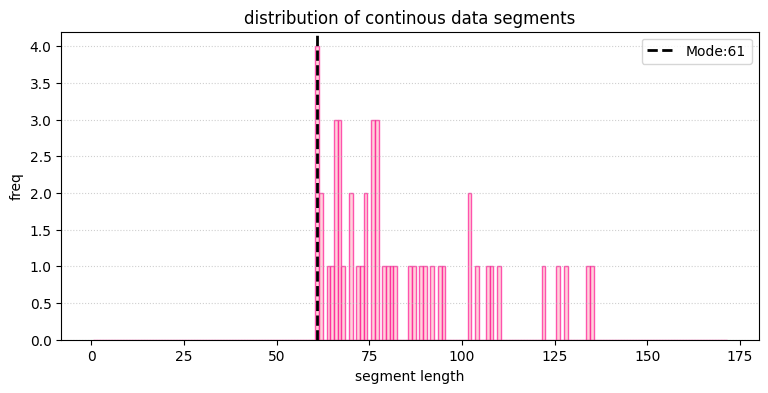

iteration done, moving to size 61
Epoch 1/30
613/613 [==============================] - 7s 10ms/step - loss: 5.6890e-04 - val_loss: 2.9059e-04
Epoch 2/30
613/613 [==============================] - 6s 9ms/step - loss: 2.4593e-04 - val_loss: 2.3689e-04
Epoch 3/30
613/613 [==============================] - 5s 9ms/step - loss: 2.2879e-04 - val_loss: 2.2830e-04
Epoch 4/30
613/613 [==============================] - 5s 9ms/step - loss: 1.3492e-04 - val_loss: 1.4422e-04
Epoch 5/30
613/613 [==============================] - 5s 9ms/step - loss: 7.6952e-05 - val_loss: 5.3002e-05
Epoch 6/30
613/613 [==============================] - 6s 9ms/step - loss: 5.1512e-05 - val_loss: 3.0398e-05
Epoch 7/30
613/613 [==============================] - 5s 9ms/step - loss: 5.2213e-05 - val_loss: 4.8813e-05
Epoch 8/30
613/613 [==============================] - 5s 9ms/step - loss: 4.6948e-05 - val_loss: 1.8916e-05
Epoch 9/30
613/613 [==============================] - 6s 9ms/step - loss: 4.6369e-05 - val_loss: 3.18

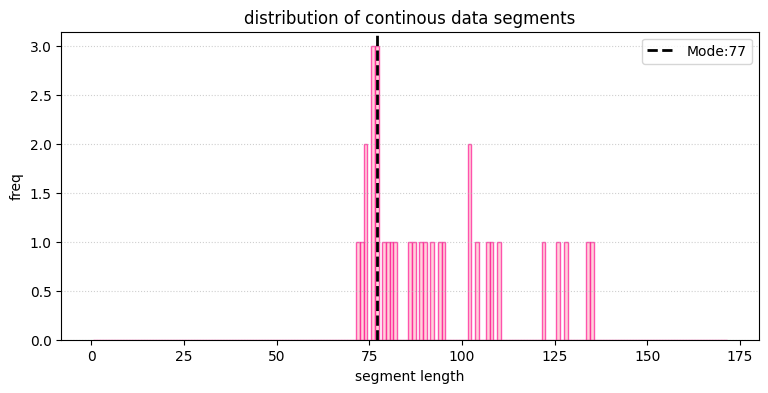

iteration done, moving to size 77
Epoch 1/30
411/411 [==============================] - 7s 14ms/step - loss: 5.9472e-04 - val_loss: 2.4618e-04
Epoch 2/30
411/411 [==============================] - 6s 14ms/step - loss: 1.8361e-04 - val_loss: 1.0157e-04
Epoch 3/30
411/411 [==============================] - 6s 14ms/step - loss: 1.0441e-04 - val_loss: 1.6216e-04
Epoch 4/30
411/411 [==============================] - 6s 14ms/step - loss: 7.6055e-05 - val_loss: 7.3092e-05
Epoch 5/30
411/411 [==============================] - 5s 13ms/step - loss: 5.3703e-05 - val_loss: 2.3300e-05
Epoch 6/30
411/411 [==============================] - 5s 13ms/step - loss: 6.4104e-05 - val_loss: 5.2054e-05
Epoch 7/30
411/411 [==============================] - 5s 13ms/step - loss: 5.6973e-05 - val_loss: 3.7836e-05
Epoch 8/30
411/411 [==============================] - 5s 13ms/step - loss: 6.1368e-05 - val_loss: 2.5424e-05
Epoch 9/30
411/411 [==============================] - 5s 13ms/step - loss: 4.8442e-05 - val_lo

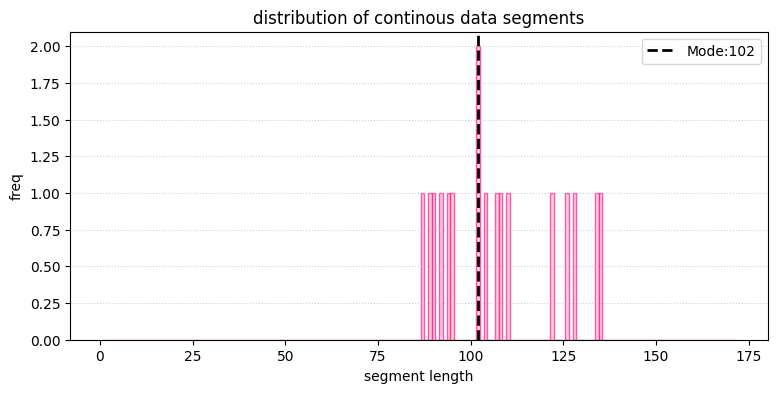

iteration done, moving to size 102
Epoch 1/30
224/224 [==============================] - 4s 13ms/step - loss: 9.3382e-04 - val_loss: 4.4305e-04
Epoch 2/30
224/224 [==============================] - 3s 12ms/step - loss: 2.0984e-04 - val_loss: 4.0977e-04
Epoch 3/30
224/224 [==============================] - 3s 12ms/step - loss: 2.0188e-04 - val_loss: 4.3412e-04
Epoch 4/30
224/224 [==============================] - 3s 13ms/step - loss: 1.9283e-04 - val_loss: 4.4056e-04
Epoch 5/30
224/224 [==============================] - 3s 12ms/step - loss: 2.0665e-04 - val_loss: 3.6542e-04
Epoch 6/30
224/224 [==============================] - 3s 12ms/step - loss: 2.0781e-04 - val_loss: 2.3516e-04
Epoch 7/30
224/224 [==============================] - 3s 13ms/step - loss: 1.9932e-04 - val_loss: 2.5484e-04
Epoch 8/30
224/224 [==============================] - 3s 12ms/step - loss: 1.7173e-04 - val_loss: 1.2995e-04
Epoch 9/30
224/224 [==============================] - 3s 13ms/step - loss: 1.3235e-04 - val_l

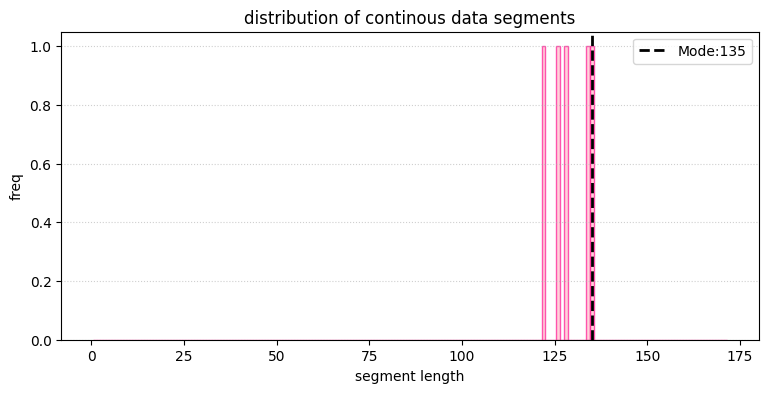

iteration done, moving to size 135
Epoch 1/30
122/122 [==============================] - 3s 20ms/step - loss: 0.0016 - val_loss: 2.4284e-04
Epoch 2/30
122/122 [==============================] - 2s 17ms/step - loss: 1.8218e-04 - val_loss: 2.1019e-04
Epoch 3/30
122/122 [==============================] - 2s 18ms/step - loss: 1.8406e-04 - val_loss: 1.8130e-04
Epoch 4/30
122/122 [==============================] - 2s 20ms/step - loss: 1.8105e-04 - val_loss: 2.6707e-04
Epoch 5/30
122/122 [==============================] - 2s 20ms/step - loss: 1.9138e-04 - val_loss: 3.3708e-04
Epoch 6/30
122/122 [==============================] - 2s 19ms/step - loss: 1.8353e-04 - val_loss: 2.8707e-04
Epoch 7/30
122/122 [==============================] - 2s 19ms/step - loss: 1.9658e-04 - val_loss: 1.8780e-04
Epoch 8/30
122/122 [==============================] - 2s 19ms/step - loss: 1.8507e-04 - val_loss: 3.0522e-04
Epoch 9/30
122/122 [==============================] - 2s 19ms/step - loss: 1.7790e-04 - val_loss:

In [66]:
# updated method with training data from alongshore transects
savepath=r'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/L2R_results_prelim/building_upL2R/iteration3'
# grabbing transect for predictions
#transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_73_nodune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)
training_ds=selected_transects.copy() # this is no dune
# starting vars
historical_stages_zoo={}
total_iterations=8
current_window_size=10 # start size
pipeline_history={}
summary_stats=[]

for iteration in range (1,total_iterations+1):
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size/2))# need for metrics (where are gaps)
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)

    # unscale data for plotting
    #recon_phys_df=unscale_dataframe(reconstructed_df,global_scaler)
    #orig_phys_df=transect_df_raw.copy()
    #recon_phys_df[original_baseline_no_dune.isna()]=np.nan
    
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    #save_stage_gaps_video_animation(orig_full_df=train_df_norm,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)

    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")
    


In [67]:
df=pd.concat([transect_73.iloc[:200],reconstructed_df],ignore_index=True)
#df_un_norm=denormalize(df)
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration3_transects_norm.csv",index=False)

ITERATION 4: 10 Transects on either side

In [68]:
#Grab transects closest to 7.3 for training
targets = ['transect_y4', 'transect_y9.3','transect_y2','transect_y0','transect_y-2','transect_y-4','transect_y12.3','transect_y15.3','transect_y18.3','transect_y21.3','transect_y-6','transect_y-8','transect_y-10','transect_y-12','transect_y-14']

selected_transects = train_df_norm_nodune.query("transect_name in @targets")
print(selected_transects)

                               0    1    2    3    4    5    6    7    8    \
transect_name  original_index                                                
transect_y-14  0               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               1               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               2               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               3               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               4               NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
...                            ...  ...  ...  ...  ...  ...  ...  ...  ...   
transect_y21.3 546             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               547             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               548             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               549             NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN  NaN   
               550             NaN  NaN  NaN  NaN  NaN  NaN  NaN

total windows found: 36127
shortest window: 1
longest window: 434


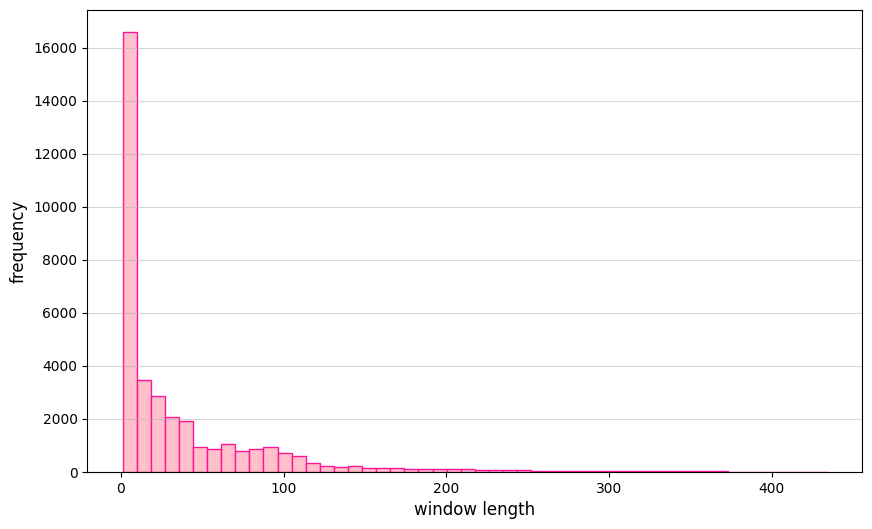

1. length: 25    frequency: 487
2. length: 12    frequency: 460
3. length: 11    frequency: 422
4. length: 21    frequency: 400
5. length: 14    frequency: 380


In [69]:
lengths_by_col,total_lengths_list=what_window_sizes(selected_transects)

print(f"total windows found: {len(total_lengths_list)}")
print(f"shortest window: {np.min(total_lengths_list)}")
print(f"longest window: {np.max(total_lengths_list)}")

plt.figure(figsize=(10,6))

unique_lens=len(set(total_lengths_list))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(total_lengths_list,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.grid(axis="y",alpha=0.5)
plt.show()

filtered_lengths=[length for length in total_lengths_list if length>10]
length_counts=Counter(filtered_lengths)
top_five=length_counts.most_common(5)

for rank,(length,freq) in enumerate(top_five,1):
    print(f"{rank}. length: {length:<5} frequency: {freq:,}")

Epoch 1/30
9413/9413 [==============================] - 161s 17ms/step - loss: 2.0779e-04 - val_loss: 1.3567e-05
Epoch 2/30
9413/9413 [==============================] - 152s 16ms/step - loss: 3.2347e-05 - val_loss: 5.1547e-05
Epoch 3/30
9413/9413 [==============================] - 139s 15ms/step - loss: 3.2580e-05 - val_loss: 3.6206e-06
Epoch 4/30
9413/9413 [==============================] - 138s 15ms/step - loss: 2.9527e-05 - val_loss: 5.5039e-06
Epoch 5/30
9413/9413 [==============================] - 151s 16ms/step - loss: 2.5264e-05 - val_loss: 1.2049e-05
Epoch 6/30
9413/9413 [==============================] - 148s 16ms/step - loss: 2.1275e-05 - val_loss: 2.0196e-06
Epoch 7/30
9413/9413 [==============================] - 153s 16ms/step - loss: 2.1179e-05 - val_loss: 1.0196e-05
Epoch 8/30
9413/9413 [==============================] - 157s 17ms/step - loss: 2.0636e-05 - val_loss: 4.7381e-06
Epoch 9/30
9413/9413 [==============================] - 149s 16ms/step - loss: 1.6834e-05 - val_

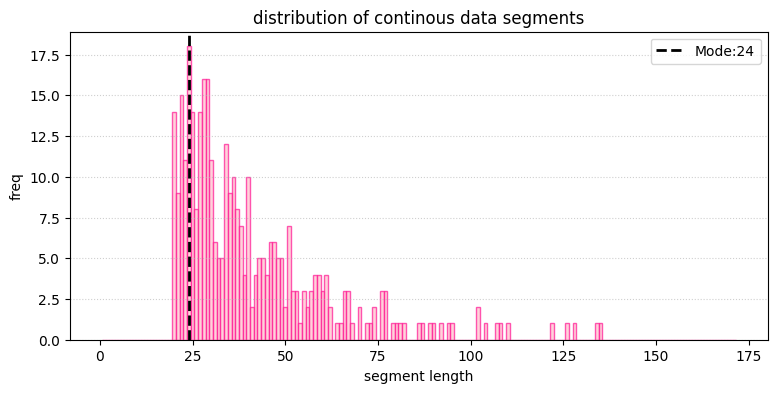

iteration done, moving to size 24
Epoch 1/30
3212/3212 [==============================] - 60s 19ms/step - loss: 5.7384e-04 - val_loss: 1.6261e-04
Epoch 2/30
3212/3212 [==============================] - 56s 18ms/step - loss: 8.1387e-05 - val_loss: 3.4746e-05
Epoch 3/30
3212/3212 [==============================] - 51s 16ms/step - loss: 3.6171e-05 - val_loss: 9.5714e-06
Epoch 4/30
3212/3212 [==============================] - 53s 17ms/step - loss: 3.3357e-05 - val_loss: 4.7217e-06
Epoch 5/30
3212/3212 [==============================] - 53s 16ms/step - loss: 3.1083e-05 - val_loss: 4.3496e-06
Epoch 6/30
3212/3212 [==============================] - 54s 17ms/step - loss: 3.1350e-05 - val_loss: 1.0473e-05
Epoch 7/30
3212/3212 [==============================] - 53s 17ms/step - loss: 2.7358e-05 - val_loss: 1.7877e-05
Epoch 8/30
3212/3212 [==============================] - 52s 16ms/step - loss: 2.7690e-05 - val_loss: 5.5359e-06
Epoch 9/30
3212/3212 [==============================] - 52s 16ms/step 

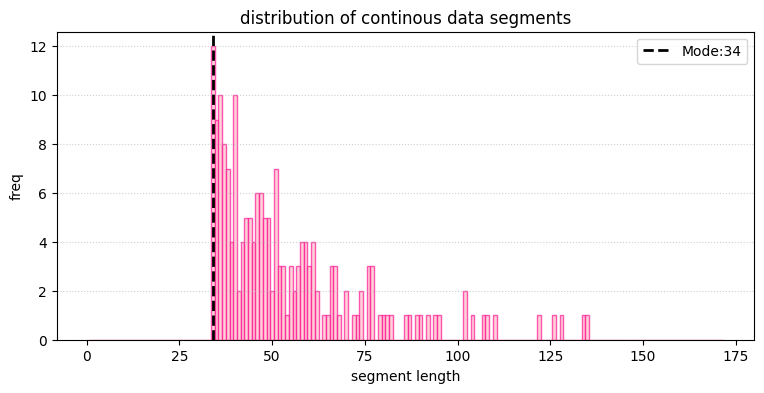

iteration done, moving to size 34
Epoch 1/30
1977/1977 [==============================] - 16s 8ms/step - loss: 4.1176e-04 - val_loss: 9.7265e-05
Epoch 2/30
1977/1977 [==============================] - 14s 7ms/step - loss: 6.3405e-05 - val_loss: 2.6534e-05
Epoch 3/30
1977/1977 [==============================] - 15s 7ms/step - loss: 4.3246e-05 - val_loss: 1.8471e-05
Epoch 4/30
1977/1977 [==============================] - 15s 7ms/step - loss: 3.8545e-05 - val_loss: 1.1394e-05
Epoch 5/30
1977/1977 [==============================] - 14s 7ms/step - loss: 4.1416e-05 - val_loss: 1.7983e-05
Epoch 6/30
1977/1977 [==============================] - 14s 7ms/step - loss: 3.5512e-05 - val_loss: 2.1556e-05
Epoch 7/30
1977/1977 [==============================] - 14s 7ms/step - loss: 3.3150e-05 - val_loss: 1.2434e-05
Epoch 8/30
1977/1977 [==============================] - 14s 7ms/step - loss: 3.0695e-05 - val_loss: 1.2211e-05
Epoch 9/30
1977/1977 [==============================] - 14s 7ms/step - loss: 2

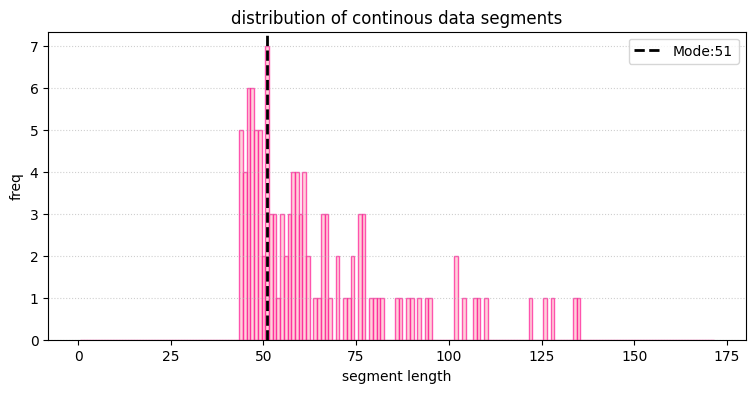

iteration done, moving to size 51
Epoch 1/30
1066/1066 [==============================] - 11s 9ms/step - loss: 4.6414e-04 - val_loss: 2.5343e-04
Epoch 2/30
1066/1066 [==============================] - 9s 8ms/step - loss: 2.1795e-04 - val_loss: 2.0165e-04
Epoch 3/30
1066/1066 [==============================] - 7s 7ms/step - loss: 8.7658e-05 - val_loss: 2.8465e-05
Epoch 4/30
1066/1066 [==============================] - 7s 7ms/step - loss: 4.8170e-05 - val_loss: 2.8686e-05
Epoch 5/30
1066/1066 [==============================] - 8s 7ms/step - loss: 4.3895e-05 - val_loss: 1.0853e-05
Epoch 6/30
1066/1066 [==============================] - 7s 7ms/step - loss: 3.7128e-05 - val_loss: 1.4493e-05
Epoch 7/30
1066/1066 [==============================] - 7s 7ms/step - loss: 3.3853e-05 - val_loss: 2.2125e-05
Epoch 8/30
1066/1066 [==============================] - 8s 7ms/step - loss: 3.5454e-05 - val_loss: 2.2054e-05
Epoch 9/30
1066/1066 [==============================] - 7s 7ms/step - loss: 3.1553e-0

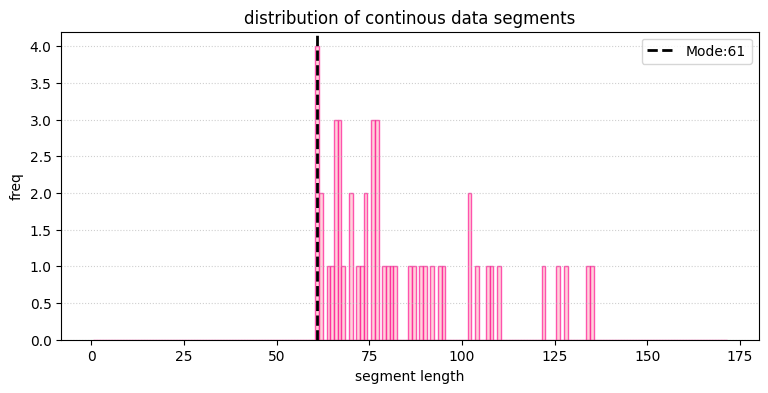

iteration done, moving to size 61
Epoch 1/30
791/791 [==============================] - 10s 11ms/step - loss: 4.6292e-04 - val_loss: 2.5435e-04
Epoch 2/30
791/791 [==============================] - 8s 10ms/step - loss: 1.9334e-04 - val_loss: 1.1177e-04
Epoch 3/30
791/791 [==============================] - 7s 9ms/step - loss: 7.5185e-05 - val_loss: 6.6788e-05
Epoch 4/30
791/791 [==============================] - 7s 9ms/step - loss: 5.4755e-05 - val_loss: 3.5875e-05
Epoch 5/30
791/791 [==============================] - 7s 8ms/step - loss: 5.2420e-05 - val_loss: 2.6938e-05
Epoch 6/30
791/791 [==============================] - 7s 9ms/step - loss: 4.1363e-05 - val_loss: 4.2342e-05
Epoch 7/30
791/791 [==============================] - 7s 9ms/step - loss: 4.6018e-05 - val_loss: 8.1331e-05
Epoch 8/30
791/791 [==============================] - 7s 9ms/step - loss: 3.5648e-05 - val_loss: 2.4928e-05
Epoch 9/30
791/791 [==============================] - 7s 9ms/step - loss: 3.6157e-05 - val_loss: 1.

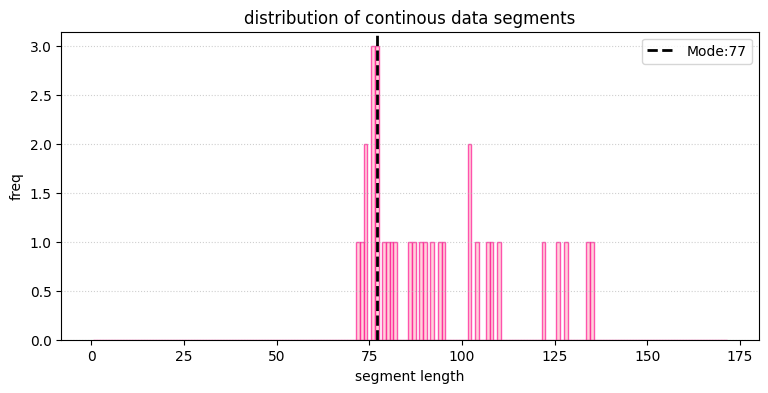

iteration done, moving to size 77
Epoch 1/30
501/501 [==============================] - 6s 10ms/step - loss: 6.0076e-04 - val_loss: 2.8606e-04
Epoch 2/30
501/501 [==============================] - 5s 9ms/step - loss: 2.1485e-04 - val_loss: 1.8816e-04
Epoch 3/30
501/501 [==============================] - 5s 9ms/step - loss: 1.0573e-04 - val_loss: 4.4020e-05
Epoch 4/30
501/501 [==============================] - 4s 8ms/step - loss: 6.2368e-05 - val_loss: 4.3730e-05
Epoch 5/30
501/501 [==============================] - 4s 9ms/step - loss: 6.1938e-05 - val_loss: 3.3840e-05
Epoch 6/30
501/501 [==============================] - 4s 9ms/step - loss: 5.3190e-05 - val_loss: 2.4330e-05
Epoch 7/30
501/501 [==============================] - 5s 9ms/step - loss: 4.8701e-05 - val_loss: 2.5008e-05
Epoch 8/30
501/501 [==============================] - 5s 9ms/step - loss: 4.5182e-05 - val_loss: 2.4032e-05
Epoch 9/30
501/501 [==============================] - 5s 10ms/step - loss: 4.2939e-05 - val_loss: 1.7

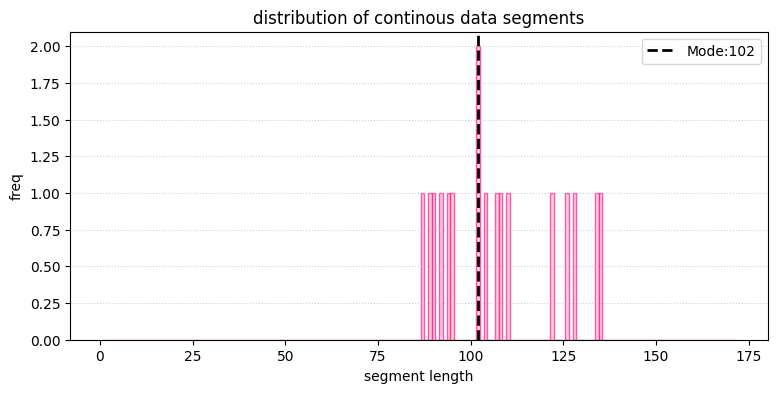

iteration done, moving to size 102
Epoch 1/30
264/264 [==============================] - 4s 13ms/step - loss: 8.2363e-04 - val_loss: 3.9722e-04
Epoch 2/30
264/264 [==============================] - 3s 11ms/step - loss: 2.0760e-04 - val_loss: 3.6870e-04
Epoch 3/30
264/264 [==============================] - 3s 11ms/step - loss: 2.0472e-04 - val_loss: 2.8244e-04
Epoch 4/30
264/264 [==============================] - 3s 11ms/step - loss: 2.0506e-04 - val_loss: 3.5000e-04
Epoch 5/30
264/264 [==============================] - 3s 12ms/step - loss: 1.9638e-04 - val_loss: 2.4925e-04
Epoch 6/30
264/264 [==============================] - 3s 11ms/step - loss: 1.8669e-04 - val_loss: 2.9119e-04
Epoch 7/30
264/264 [==============================] - 3s 11ms/step - loss: 1.8117e-04 - val_loss: 2.9404e-04
Epoch 8/30
264/264 [==============================] - 3s 11ms/step - loss: 1.9629e-04 - val_loss: 2.1542e-04
Epoch 9/30
264/264 [==============================] - 3s 11ms/step - loss: 1.7603e-04 - val_l

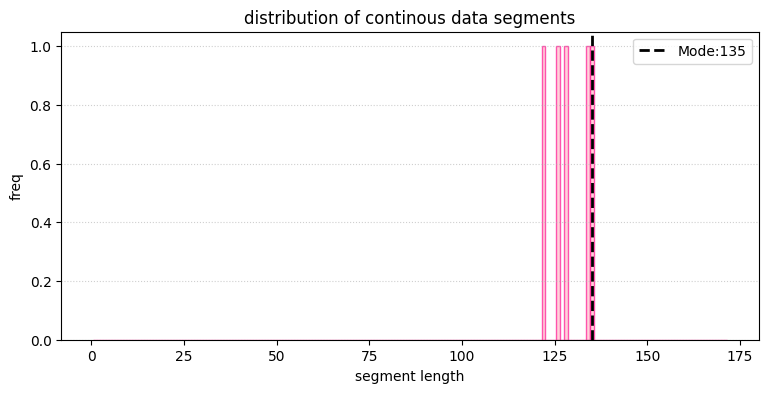

iteration done, moving to size 135
Epoch 1/30
135/135 [==============================] - 4s 23ms/step - loss: 0.0014 - val_loss: 2.3873e-04
Epoch 2/30
135/135 [==============================] - 3s 21ms/step - loss: 1.9775e-04 - val_loss: 3.2806e-04
Epoch 3/30
135/135 [==============================] - 3s 21ms/step - loss: 1.9941e-04 - val_loss: 2.9356e-04
Epoch 4/30
135/135 [==============================] - 3s 20ms/step - loss: 1.8856e-04 - val_loss: 3.8184e-04
Epoch 5/30
135/135 [==============================] - 3s 21ms/step - loss: 1.8381e-04 - val_loss: 3.9068e-04
Epoch 6/30
135/135 [==============================] - 3s 21ms/step - loss: 1.8749e-04 - val_loss: 2.7937e-04
Epoch 7/30
135/135 [==============================] - 3s 22ms/step - loss: 1.9737e-04 - val_loss: 3.4284e-04
Epoch 8/30
135/135 [==============================] - 3s 23ms/step - loss: 2.0022e-04 - val_loss: 3.1574e-04
Epoch 9/30
135/135 [==============================] - 3s 22ms/step - loss: 1.6909e-04 - val_loss:

In [70]:
# updated method with training data from alongshore transects
savepath=r'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/L2R_results_prelim/building_upL2R/iteration4'
# grabbing transect for predictions
#transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_73_nodune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)
training_ds=selected_transects.copy() # this is no dune
# starting vars
historical_stages_zoo={}
total_iterations=8
current_window_size=10 # start size
pipeline_history={}
summary_stats=[]

for iteration in range (1,total_iterations+1):
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size/2))# need for metrics (where are gaps)
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)

    # unscale data for plotting
    #recon_phys_df=unscale_dataframe(reconstructed_df,global_scaler)
    #orig_phys_df=transect_df_raw.copy()
    #recon_phys_df[original_baseline_no_dune.isna()]=np.nan
    
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    #save_stage_gaps_video_animation(orig_full_df=train_df_norm,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)

    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")
    


In [71]:
df=pd.concat([transect_73.iloc[:200],reconstructed_df],ignore_index=True)
#df_un_norm=denormalize(df)
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration4_transects_norm.csv",index=False)

ITERATION 5: All Transects

total windows found: 111154
shortest window: 1
longest window: 434


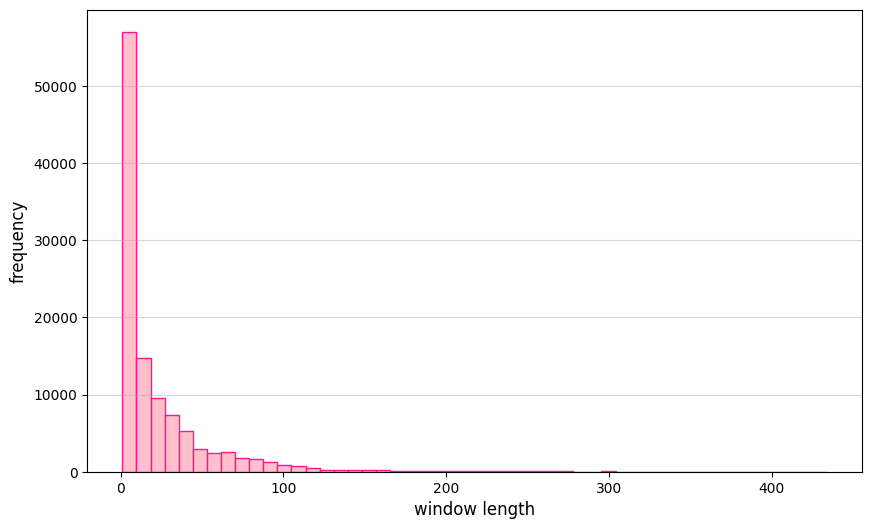

1. length: 11    frequency: 1,910
2. length: 12    frequency: 1,791
3. length: 13    frequency: 1,667
4. length: 14    frequency: 1,605
5. length: 16    frequency: 1,505


In [75]:
lengths_by_col,total_lengths_list=what_window_sizes(train_ds)

print(f"total windows found: {len(total_lengths_list)}")
print(f"shortest window: {np.min(total_lengths_list)}")
print(f"longest window: {np.max(total_lengths_list)}")

plt.figure(figsize=(10,6))

unique_lens=len(set(total_lengths_list))
bins=min(50,unique_lens) if unique_lens>0 else 10

plt.hist(total_lengths_list,bins=bins,color='pink',edgecolor='deeppink')
plt.xlabel('window length',fontsize=12)
plt.ylabel('frequency',fontsize=12)
plt.grid(axis="y",alpha=0.5)
plt.show()

filtered_lengths=[length for length in total_lengths_list if length>10]
length_counts=Counter(filtered_lengths)
top_five=length_counts.most_common(5)

for rank,(length,freq) in enumerate(top_five,1):
    print(f"{rank}. length: {length:<5} frequency: {freq:,}")

Epoch 1/30
17103/17103 [==============================] - 133s 8ms/step - loss: 1.4210e-04 - val_loss: 1.2329e-04
Epoch 2/30
17103/17103 [==============================] - 132s 8ms/step - loss: 2.3806e-05 - val_loss: 4.6752e-06
Epoch 3/30
17103/17103 [==============================] - 130s 8ms/step - loss: 2.0358e-05 - val_loss: 2.5215e-06
Epoch 4/30
17103/17103 [==============================] - 146s 9ms/step - loss: 1.5872e-05 - val_loss: 2.0095e-05
Epoch 5/30
17103/17103 [==============================] - 152s 9ms/step - loss: 1.4583e-05 - val_loss: 1.3083e-05
Epoch 6/30
17103/17103 [==============================] - 143s 8ms/step - loss: 1.4922e-05 - val_loss: 2.3963e-06
Epoch 7/30
17103/17103 [==============================] - 153s 9ms/step - loss: 1.5388e-05 - val_loss: 2.1990e-06
Epoch 8/30
17103/17103 [==============================] - 150s 9ms/step - loss: 1.5535e-05 - val_loss: 2.0994e-05
Epoch 9/30
17103/17103 [==============================] - 143s 8ms/step - loss: 1.5565e-

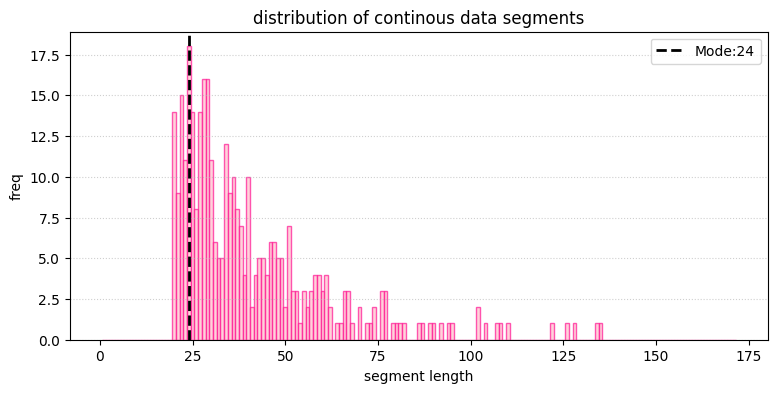

iteration done, moving to size 24
Epoch 1/30
5231/5231 [==============================] - 91s 17ms/step - loss: 2.9188e-04 - val_loss: 1.5436e-05
Epoch 2/30
5231/5231 [==============================] - 82s 16ms/step - loss: 3.2000e-05 - val_loss: 1.0492e-05
Epoch 3/30
5231/5231 [==============================] - 80s 15ms/step - loss: 2.4009e-05 - val_loss: 5.8624e-06
Epoch 4/30
5231/5231 [==============================] - 79s 15ms/step - loss: 2.1823e-05 - val_loss: 9.5934e-06
Epoch 5/30
5231/5231 [==============================] - 76s 14ms/step - loss: 2.4114e-05 - val_loss: 3.9290e-06
Epoch 6/30
5231/5231 [==============================] - 74s 14ms/step - loss: 2.0946e-05 - val_loss: 8.2829e-06
Epoch 7/30
5231/5231 [==============================] - 84s 16ms/step - loss: 1.8203e-05 - val_loss: 3.8360e-06
Epoch 8/30
5231/5231 [==============================] - 82s 16ms/step - loss: 1.7799e-05 - val_loss: 9.6605e-06
Epoch 9/30
5231/5231 [==============================] - 82s 16ms/step 

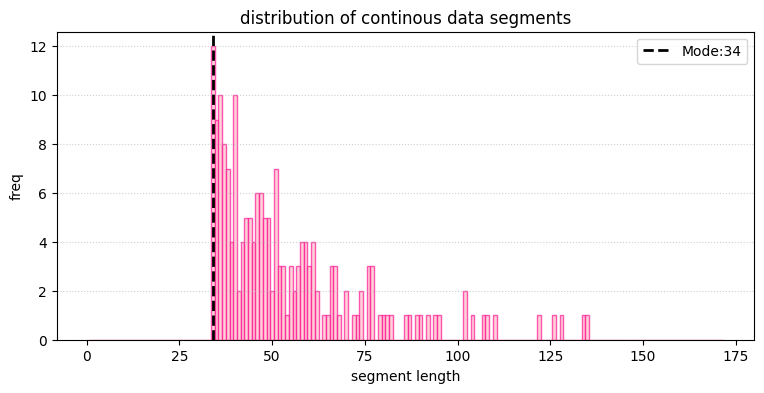

iteration done, moving to size 34
Epoch 1/30
2998/2998 [==============================] - 27s 9ms/step - loss: 4.3900e-04 - val_loss: 1.9402e-04
Epoch 2/30
2998/2998 [==============================] - 25s 8ms/step - loss: 1.1478e-04 - val_loss: 6.7195e-05
Epoch 3/30
2998/2998 [==============================] - 25s 8ms/step - loss: 3.9363e-05 - val_loss: 1.2404e-05
Epoch 4/30
2998/2998 [==============================] - 25s 8ms/step - loss: 3.1413e-05 - val_loss: 2.4680e-05
Epoch 5/30
2998/2998 [==============================] - 26s 9ms/step - loss: 2.7034e-05 - val_loss: 4.0359e-05
Epoch 6/30
2998/2998 [==============================] - 25s 8ms/step - loss: 2.6499e-05 - val_loss: 9.8222e-06
Epoch 7/30
2998/2998 [==============================] - 25s 8ms/step - loss: 3.0748e-05 - val_loss: 1.6640e-05
Epoch 8/30
2998/2998 [==============================] - 26s 9ms/step - loss: 2.1612e-05 - val_loss: 9.1522e-06
Epoch 9/30
2998/2998 [==============================] - 26s 9ms/step - loss: 2

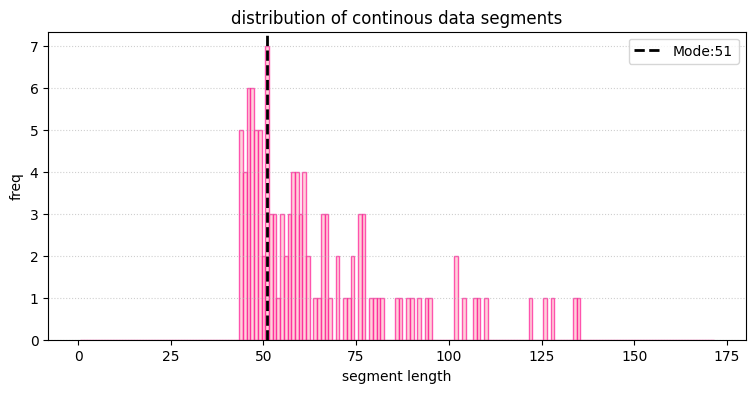

iteration done, moving to size 51
Epoch 1/30
1453/1453 [==============================] - 16s 11ms/step - loss: 3.7201e-04 - val_loss: 2.0785e-04
Epoch 2/30
1453/1453 [==============================] - 15s 10ms/step - loss: 1.6364e-04 - val_loss: 9.4199e-05
Epoch 3/30
1453/1453 [==============================] - 13s 9ms/step - loss: 6.0158e-05 - val_loss: 3.6349e-05
Epoch 4/30
1453/1453 [==============================] - 13s 9ms/step - loss: 4.1652e-05 - val_loss: 2.2556e-05
Epoch 5/30
1453/1453 [==============================] - 13s 9ms/step - loss: 4.1189e-05 - val_loss: 2.2660e-05
Epoch 6/30
1453/1453 [==============================] - 13s 9ms/step - loss: 3.6090e-05 - val_loss: 1.6384e-05
Epoch 7/30
1453/1453 [==============================] - 13s 9ms/step - loss: 2.8645e-05 - val_loss: 1.6825e-05
Epoch 8/30
1453/1453 [==============================] - 14s 10ms/step - loss: 2.7965e-05 - val_loss: 1.8994e-05
Epoch 9/30
1453/1453 [==============================] - 15s 10ms/step - los

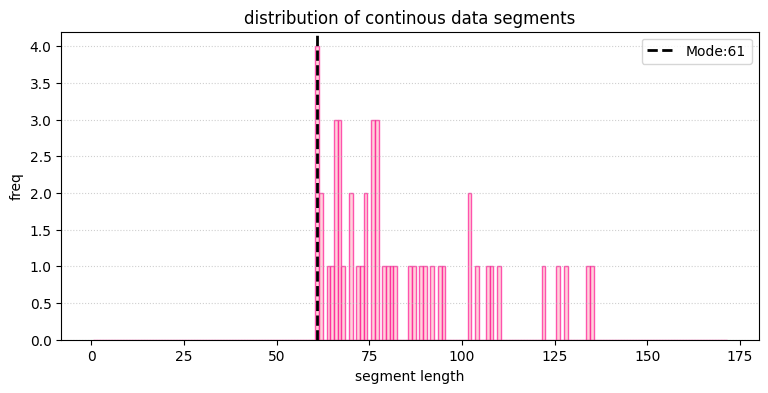

iteration done, moving to size 61
Epoch 1/30
1023/1023 [==============================] - 13s 11ms/step - loss: 4.3834e-04 - val_loss: 2.3431e-04
Epoch 2/30
1023/1023 [==============================] - 11s 11ms/step - loss: 1.1892e-04 - val_loss: 2.7069e-05
Epoch 3/30
1023/1023 [==============================] - 11s 11ms/step - loss: 5.0574e-05 - val_loss: 2.2745e-05
Epoch 4/30
1023/1023 [==============================] - 11s 10ms/step - loss: 4.4409e-05 - val_loss: 1.1466e-05
Epoch 5/30
1023/1023 [==============================] - 11s 11ms/step - loss: 3.6842e-05 - val_loss: 1.8096e-05
Epoch 6/30
1023/1023 [==============================] - 11s 11ms/step - loss: 3.9174e-05 - val_loss: 2.5290e-05
Epoch 7/30
1023/1023 [==============================] - 11s 11ms/step - loss: 3.5693e-05 - val_loss: 1.6872e-05
Epoch 8/30
1023/1023 [==============================] - 12s 11ms/step - loss: 3.3666e-05 - val_loss: 1.1548e-05
Epoch 9/30
1023/1023 [==============================] - 11s 11ms/step 

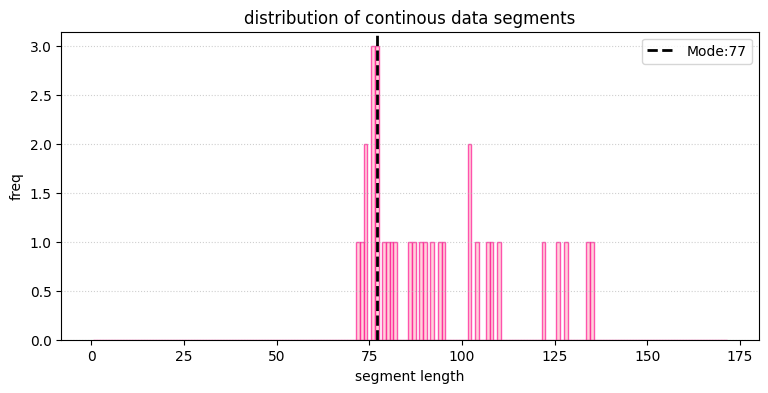

iteration done, moving to size 77
Epoch 1/30
598/598 [==============================] - 9s 13ms/step - loss: 5.8704e-04 - val_loss: 3.2079e-04
Epoch 2/30
598/598 [==============================] - 8s 13ms/step - loss: 2.0600e-04 - val_loss: 2.6697e-04
Epoch 3/30
598/598 [==============================] - 8s 14ms/step - loss: 1.5159e-04 - val_loss: 6.8217e-05
Epoch 4/30
598/598 [==============================] - 8s 13ms/step - loss: 8.2828e-05 - val_loss: 1.9951e-05
Epoch 5/30
598/598 [==============================] - 7s 12ms/step - loss: 6.5492e-05 - val_loss: 5.8892e-05
Epoch 6/30
598/598 [==============================] - 7s 12ms/step - loss: 5.7944e-05 - val_loss: 6.7991e-05
Epoch 7/30
598/598 [==============================] - 7s 11ms/step - loss: 5.3896e-05 - val_loss: 4.8378e-05
Epoch 8/30
598/598 [==============================] - 8s 13ms/step - loss: 4.7363e-05 - val_loss: 3.6017e-05
Epoch 9/30
598/598 [==============================] - 8s 13ms/step - loss: 4.1248e-05 - val_lo

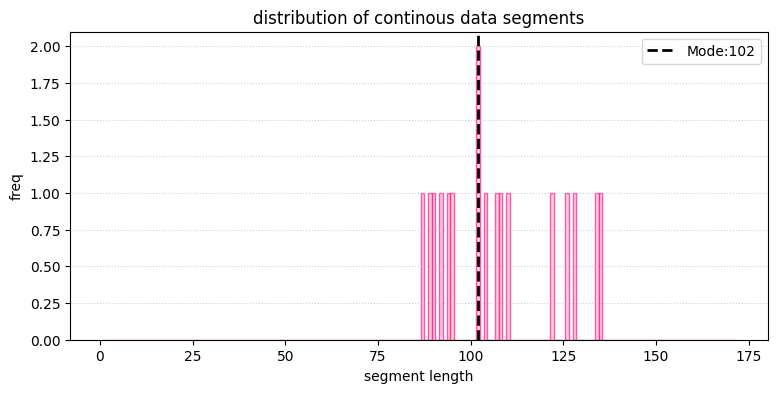

iteration done, moving to size 102
Epoch 1/30
285/285 [==============================] - 5s 14ms/step - loss: 7.6008e-04 - val_loss: 3.1834e-04
Epoch 2/30
285/285 [==============================] - 4s 14ms/step - loss: 1.9140e-04 - val_loss: 1.8952e-04
Epoch 3/30
285/285 [==============================] - 4s 13ms/step - loss: 1.9933e-04 - val_loss: 2.3098e-04
Epoch 4/30
285/285 [==============================] - 4s 14ms/step - loss: 2.0289e-04 - val_loss: 2.9448e-04
Epoch 5/30
285/285 [==============================] - 4s 14ms/step - loss: 1.8878e-04 - val_loss: 2.0151e-04
Epoch 6/30
285/285 [==============================] - 4s 14ms/step - loss: 1.7856e-04 - val_loss: 2.4545e-04
Epoch 7/30
285/285 [==============================] - 4s 14ms/step - loss: 1.7459e-04 - val_loss: 2.1547e-04
Epoch 8/30
285/285 [==============================] - 4s 14ms/step - loss: 1.4230e-04 - val_loss: 1.8689e-04
Epoch 9/30
285/285 [==============================] - 4s 14ms/step - loss: 1.1577e-04 - val_l

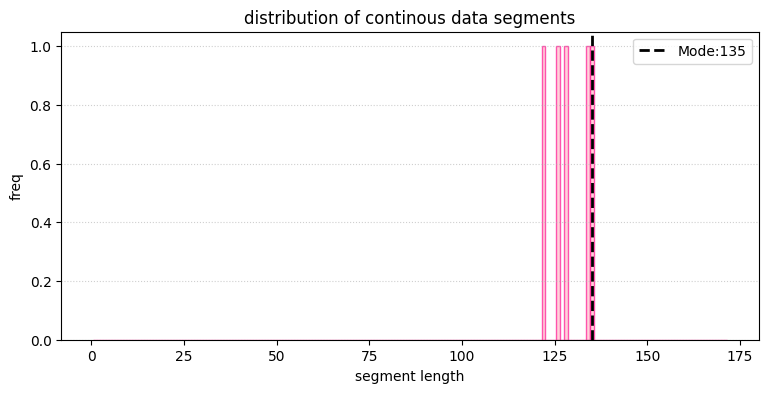

iteration done, moving to size 135
Epoch 1/30
139/139 [==============================] - 4s 25ms/step - loss: 0.0014 - val_loss: 1.6365e-04
Epoch 2/30
139/139 [==============================] - 3s 24ms/step - loss: 1.8764e-04 - val_loss: 2.0425e-04
Epoch 3/30
139/139 [==============================] - 3s 24ms/step - loss: 1.8210e-04 - val_loss: 2.0343e-04
Epoch 4/30
139/139 [==============================] - 3s 23ms/step - loss: 1.8445e-04 - val_loss: 2.6630e-04
Epoch 5/30
139/139 [==============================] - 3s 23ms/step - loss: 1.8779e-04 - val_loss: 2.2013e-04
Epoch 6/30
139/139 [==============================] - 3s 23ms/step - loss: 1.7406e-04 - val_loss: 2.2978e-04
Epoch 7/30
139/139 [==============================] - 3s 23ms/step - loss: 1.6936e-04 - val_loss: 1.8924e-04
Epoch 8/30
139/139 [==============================] - 3s 24ms/step - loss: 1.7691e-04 - val_loss: 2.3593e-04
Epoch 9/30
139/139 [==============================] - 3s 24ms/step - loss: 1.6309e-04 - val_loss:

In [76]:
# updated method with training data from alongshore transects
savepath=r'/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/Figures/L2R_results_prelim/building_upL2R/iteration5'
# grabbing transect for predictions
#transect_df_norm_noDune=transect_df_norm.iloc[200:]
original_baseline_no_dune=transect_73_nodune.copy()
current_dataset=original_baseline_no_dune.copy()
original_data_mask=(~np.isnan(current_dataset)).astype(float)
active_mask=(~np.isnan(current_dataset)).astype(float)
training_ds=train_df_norm_nodune.copy() # this is no dune
# starting vars
historical_stages_zoo={}
total_iterations=8
current_window_size=10 # start size
pipeline_history={}
summary_stats=[]

for iteration in range (1,total_iterations+1):
    # map of gaps in transect for training (where is there data)
    current_windows_idx=find_windows_of_data(training_ds,window_size=current_window_size,overlap_stride=int(current_window_size/2))
    # prep alongshore transect windows of given size (add in part where you grab inbtween windows) (training data)
    tf_train,tf_val,tf_test=prep_training(train_source_df=training_ds,split_windows_idx=current_windows_idx,batch_size=16)
    # run model
    trained_model,history=run_MAE(window_size=current_window_size,train_ds=tf_train,val_ds=tf_val,epochs=30)
    # reconstruct transect
    reconstructed_df=reconstruct_ds_with_MAE(model=trained_model,current_df=current_dataset,active_mask_df=active_mask,window_size=current_window_size,stride=5)
    # store results
    eval_windows_idx=find_windows_of_data(current_dataset,window_size=current_window_size, overlap_stride=int(current_window_size/2))# need for metrics (where are gaps)
    stage_name=f"stage_{iteration}_size_{current_window_size}"
    historical_stages_zoo[stage_name]=reconstructed_df
    print("plotting error and loss")
    save_stage_loss_plot(history=history,window_size=current_window_size,stage_dir=savepath)
    # update for loop
    current_dataset=reconstructed_df
    active_mask=(~np.isnan(current_dataset)).astype(float)

    # unscale data for plotting
    #recon_phys_df=unscale_dataframe(reconstructed_df,global_scaler)
    #orig_phys_df=transect_df_raw.copy()
    #recon_phys_df[original_baseline_no_dune.isna()]=np.nan
    
    # save stats
    pipeline_history[current_window_size]={"model":trained_model,"history":history,"dataset_after_stage": reconstructed_df.copy()}
    print("plotting static timesteps")
    save_stage_comparison_plots(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath)
    print("video of reconstruction")
    save_stage_video_animation(orig_full_df=transect_73, recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)
    #save_stage_gaps_video_animation(orig_full_df=train_df_norm,recon_no_dune_df=reconstructed_df,window_size=current_window_size,stage_dir=savepath,interval=500)

    # check next window size up
    if iteration<total_iterations:
        floor=current_window_size+10

        current_mode=reeval_and_hist(active_mask_df=active_mask,min_length=floor,target_val=0,plot_histogram=True,stage_label=f"post {stage_name}")

    if current_mode is not None:
        if current_mode<=current_window_size:
            current_window_size=current_window_size+15
        else:
            current_window_size=int(current_mode)

    print(f"iteration done, moving to size {current_mode}")
    


In [74]:
df=pd.concat([transect_73.iloc[:200],reconstructed_df],ignore_index=True)
#df_un_norm=denormalize(df)
df.to_csv("/Volumes/Elements/StormCHAZerz Data/Dec2023Noreaster_processed/1702827001820/MAE_data/L2R_buildingUp/iteration5_transects_norm.csv",index=False)

Compare results from each iteration